# Análisis del dataset final

## Import librerías y dataset

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import re
import unicodedata

In [18]:
# Carga del dataset 
try:
    df = pd.read_csv('data/merged_all_clean.csv')
    
    if 'SEQN' in df.columns:
        df.drop(columns=['SEQN'], inplace=True)
        print("Columna 'SEQN' eliminada.")
        print(f"Dataset cargado con éxito: {df.shape[0]} filas y {df.shape[1]} columnas.")
        print(df.columns.tolist())
    else:
        print("No se encontró columna 'SEQN'.")
        print(f"Dataset cargado con éxito: {df.shape[0]} filas y {df.shape[1]} columnas.")
        print(df.columns.tolist())
        
except FileNotFoundError:
    print("Error: No se encontró el archivo 'all_merged_clean.csv' en la carpeta 'data/'.")

Columna 'SEQN' eliminada.
Dataset cargado con éxito: 2687 filas y 124 columnas.
['SDDSRVYR', 'RIDSTATR', 'RIAGENDR', 'RIDAGEYR', 'RIDRETH1', 'RIDRETH3', 'RIDEXMON', 'DMDBORN4', 'DMDHHSIZ', 'WTINT2YR', 'WTMEC2YR', 'SDMVSTRA', 'SDMVPSU', 'INDFMPIR', 'WTDRD1', 'DSDCOUNT', 'DSDANCNT', 'DSD010', 'DSD010AN', 'BAXMSTAT', 'BAX5STAT', 'BAQ110', 'BAQ121', 'BAQ125', 'BAQ132', 'BAQ140', 'BAQ150', 'BAQ160', 'BAQ170', 'BAQ173', 'BAXPF11', 'BAXTC11', 'BAXPF21', 'BAXTC21', 'BAXPF31', 'BAXTC31', 'BAXPF41', 'BAXTC41', 'BPAOARM', 'BPAOCSZ', 'BPXOSY1', 'BPXODI1', 'BPXOSY2', 'BPXODI2', 'BPXOSY3', 'BPXODI3', 'BPXOPLS1', 'BPXOPLS2', 'BPXOPLS3', 'BMDSTATS', 'BMXWT', 'BMXHT', 'BMXBMI', 'BMXLEG', 'BMXARML', 'BMXARMC', 'BMXWAIST', 'BMXHIP', 'LUAXSTAT', 'LUAPNME', 'LUANMVGP', 'LUANMTGP', 'LUXSMED', 'LUXSIQR', 'LUXSIQRM', 'LUXCAPM', 'LUXCPIQR', 'URXUMA', 'URXUMS', 'URDUMALC', 'URXUCR', 'URXCRS', 'URDUCRLC', 'URDACT', 'WTPH2YR', 'LBXWBCSI', 'LBXLYPCT', 'LBXMOPCT', 'LBXNEPCT', 'LBXEOPCT', 'LBXBAPCT', 'LBDLYMNO', 'LB

In [19]:
# 1. Cargar diccionario
ruta_diccionario = "data/Diccionario_TFM_Completo.xlsx"
diccionario = pd.read_excel(ruta_diccionario)

# 2. Limpiar columnas del diccionario
diccionario['Columna'] = diccionario['Columna'].astype(str).str.strip()
diccionario['Qué es'] = diccionario['Qué es'].astype(str).str.strip()

# 3. Función para limpiar nombres (ML friendly)
def limpiar_nombre(col):
    col = col.lower()
    col = col.replace(" ", "_")
    col = re.sub(r'[^a-z0-9_]', '', col)
    return col

# 4. Crear mapping limpio (old -> new)
mapping = dict(zip(diccionario['Columna'], diccionario['Qué es']))
mapping_filtrado = {k: limpiar_nombre(v) for k, v in mapping.items() if k in df.columns}

print(f"Columnas que se van a renombrar: {len(mapping_filtrado)}")

# 5. Renombrar dataset
df = df.rename(columns=mapping_filtrado)

# 6. Verificación
print("\nEjemplo de columnas renombradas:")
for old, new in list(mapping_filtrado.items()):
    print(f"{old} → {new}")

# 7. Columnas sin diccionario
columnas_sin_diccionario = [col for col in df.columns if col not in mapping_filtrado.values()]

print(f"\nColumnas sin renombrar: {len(columnas_sin_diccionario)}")
print(columnas_sin_diccionario)

Columnas que se van a renombrar: 124

Ejemplo de columnas renombradas:
SDDSRVYR → ciclo
RIDSTATR → estado
RIAGENDR → gnero
RIDAGEYR → edad
RIDRETH1 → etnia_1
RIDRETH3 → etnia_3
RIDEXMON → mes_examen
DMDBORN4 → pas_nacimiento
DMDHHSIZ → tamao_hogar
WTINT2YR → peso_entrevista
WTMEC2YR → peso_examen
SDMVSTRA → estrato
SDMVPSU → psu
INDFMPIR → ratio_pobreza
WTDRD1 → peso_dieta
DSDCOUNT → total_suplementos
DSDANCNT → total_anticidos
DSD010 → uso_suplementos
DSD010AN → uso_anticidos
BAXMSTAT → estado_equilibrio
BAX5STAT → estado_romberg
BAQ110 → mareos
BAQ121 → desmayos
BAQ125 → convulsiones
BAQ132 → dificultad_caminar
BAQ140 → cadas
BAQ150 → fracturas
BAQ160 → test_densidad
BAQ170 → med_osteoporosis
BAQ173 → diag_osteoporosis
BAXPF11 → romberg_1_res
BAXTC11 → romberg_1_seg
BAXPF21 → romberg_2_res
BAXTC21 → romberg_2_seg
BAXPF31 → romberg_3_res
BAXTC31 → romberg_3_seg
BAXPF41 → romberg_4_res
BAXTC41 → romberg_4_seg
BPAOARM → brazo
BPAOCSZ → manguito
BPXOSY1 → sistlica_1
BPXODI1 → diastlica_1

- Tras cerrar este apartado nos hemos quedado con el dataset sin la columna identificador y se han cambiado los nombres de las variables por otros más interpretables.

## Análisis Variables

In [20]:
# 1. Definición de categóricas utilizando el diccionario
  # Como ya importamos el diccionario en la celda anterior para renombrar no volvemos a importar. 

def normalizar_texto(x):
    x = str(x).strip().lower()
    x = unicodedata.normalize("NFKD", x).encode("ascii", "ignore").decode("utf-8")
    return x

diccionario["Tipo de Variable"] = diccionario["Tipo de Variable"].apply(normalizar_texto)

cols_categoricas = diccionario.loc[
    diccionario["Tipo de Variable"].str.contains("categ", na=False), "Qué es"
].tolist()
cols_categoricas = [limpiar_nombre(col) for col in cols_categoricas]

print(f"Número de columnas categóricas: {len(cols_categoricas)}")
print(cols_categoricas)

Número de columnas categóricas: 37
['ciclo', 'estado', 'gnero', 'etnia_1', 'etnia_3', 'mes_examen', 'pas_nacimiento', 'uso_suplementos', 'uso_anticidos', 'estado_equilibrio', 'estado_romberg', 'mareos', 'desmayos', 'convulsiones', 'dificultad_caminar', 'cadas', 'fracturas', 'test_densidad', 'med_osteoporosis', 'diag_osteoporosis', 'romberg_1_res', 'romberg_2_res', 'romberg_3_res', 'romberg_4_res', 'brazo', 'manguito', 'estado_antropo', 'estado_hgado', 'sonda', 'com_albmina', 'com_creatinina', 'com_pcr', 'com_plomo', 'com_cadmio', 'com_mercurio', 'com_selenio', 'com_manganeso']


In [7]:
# 2. Filtrar solo las presentes
cols_categoricas_presentes = [col for col in cols_categoricas if col in df.columns]

# 3. Convertir a category
for col in cols_categoricas_presentes:
    df[col] = df[col].astype('category')

# 4. Identificar numéricas
cols_numericas = df.columns.difference(cols_categoricas_presentes).tolist()

# 5. Verificación CORRECTA
print(f"--- Clasificación Manual Completada ---")
print(f"Variables categóricas (esperadas): {len(cols_categoricas_presentes)}")
print(f"Variables numéricas: {len(cols_numericas)}")

# Conteo correcto de tipos
print("\nResumen de tipos de datos:")
print(df.dtypes.astype(str).value_counts())

# 6. Diagnóstico 
print("\nColumnas categóricas detectadas:")
print(df.select_dtypes(include='category').columns.tolist())

print("\nColumnas object (revisar si deberían ser categóricas):")
print(df.select_dtypes(include='object').columns.tolist())

# Ver qué variables no estaban en el dataset
cols_faltantes = [col for col in cols_categoricas if col not in df.columns]

print(f"\nCategóricas presentes: {len(cols_categoricas_presentes)}")
print(f"Categóricas faltantes: {len(cols_faltantes)}")

--- Clasificación Manual Completada ---
Variables categóricas (esperadas): 37
Variables numéricas: 87

Resumen de tipos de datos:
float64     87
category    37
Name: count, dtype: int64

Columnas categóricas detectadas:
['ciclo', 'estado', 'gnero', 'etnia_1', 'etnia_3', 'mes_examen', 'pas_nacimiento', 'uso_suplementos', 'uso_anticidos', 'estado_equilibrio', 'estado_romberg', 'mareos', 'desmayos', 'convulsiones', 'dificultad_caminar', 'cadas', 'fracturas', 'test_densidad', 'med_osteoporosis', 'diag_osteoporosis', 'romberg_1_res', 'romberg_2_res', 'romberg_3_res', 'romberg_4_res', 'brazo', 'manguito', 'estado_antropo', 'estado_hgado', 'sonda', 'com_albmina', 'com_creatinina', 'com_pcr', 'com_plomo', 'com_cadmio', 'com_mercurio', 'com_selenio', 'com_manganeso']

Columnas object (revisar si deberían ser categóricas):
[]

Categóricas presentes: 37
Categóricas faltantes: 0


### Distribución de Categóricas

Tras haber definifo las variables categóricas procedemos a observar la distribución y a buscar si se pudiese combinar variables de este tipo.

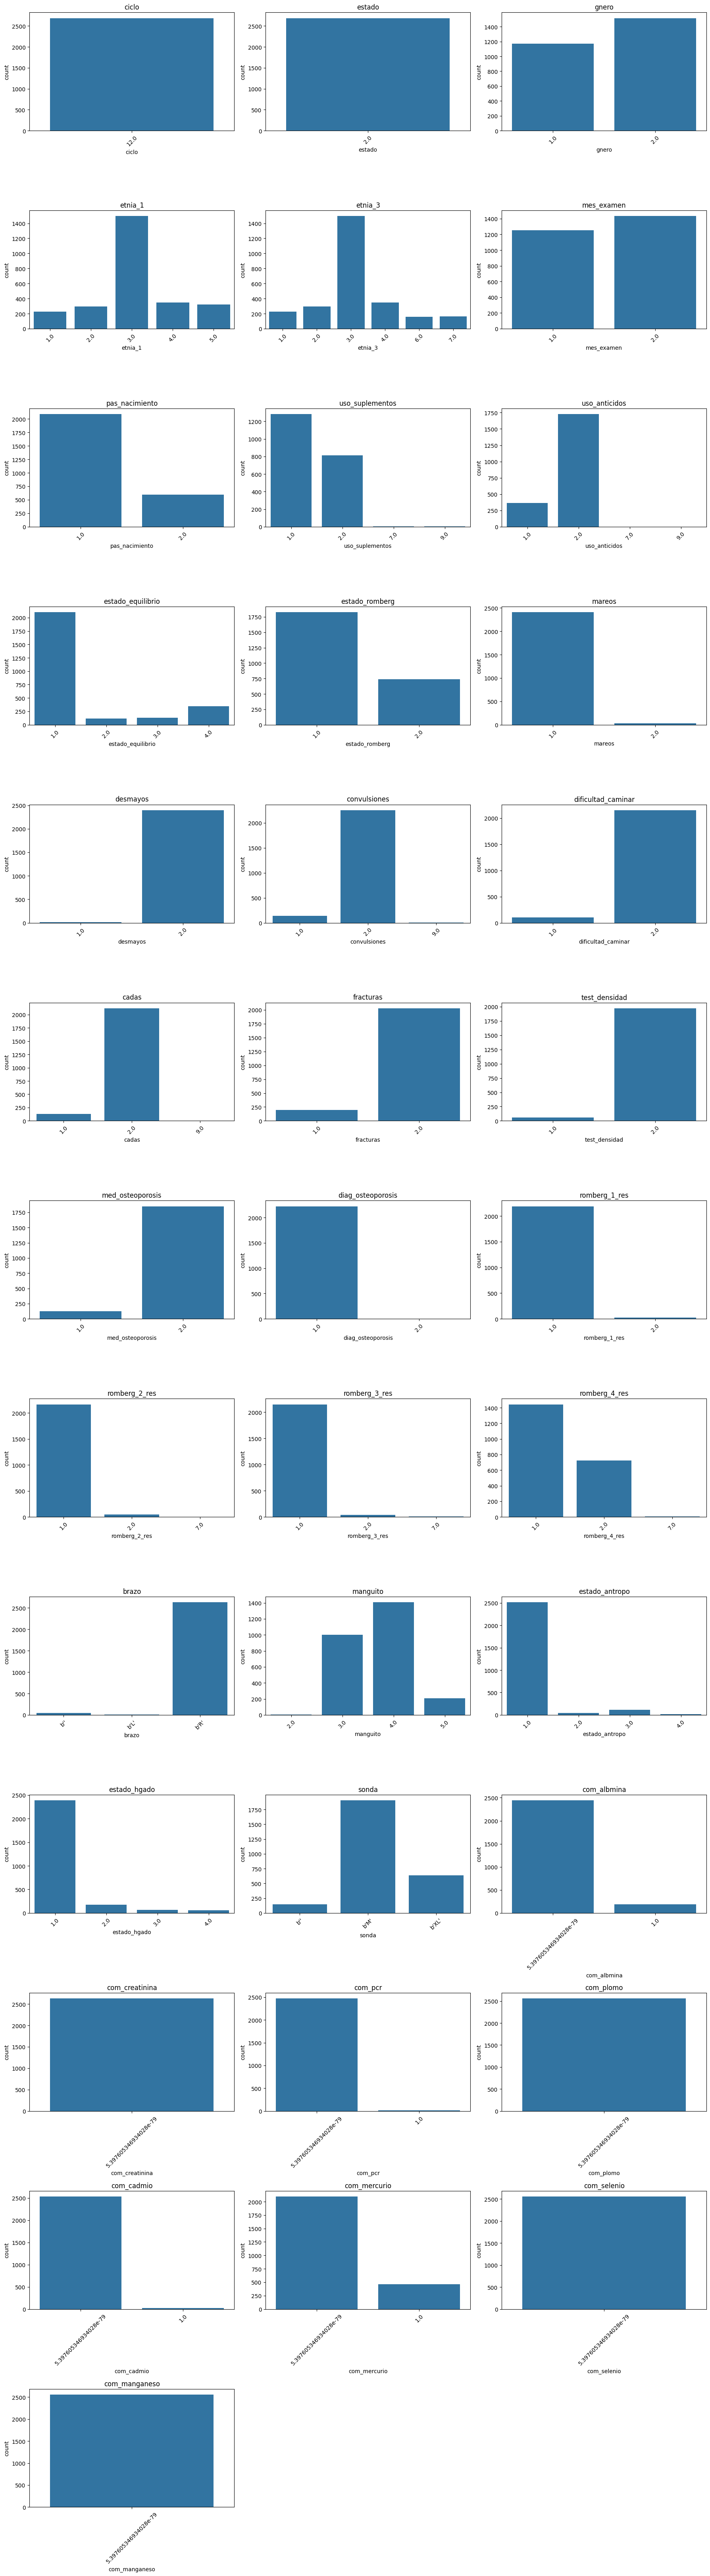

In [ ]:
# 1. Configuración
n_cols = 3  # nº de gráficos por fila
n_vars = len(cols_categoricas)
n_rows = (n_vars // n_cols) + 1

plt.figure(figsize=(18, 5 * n_rows))

# 2. Loop por variables categóricas
for i, col in enumerate(cols_categoricas):
    plt.subplot(n_rows, n_cols, i + 1)
    
    # Conteo de valores
    conteo = df[col].value_counts().reset_index()
    conteo.columns = [col, 'count']
    
    # Barplot
    sns.barplot(data=conteo, x=col, y='count')
    
    plt.title(col)
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()
#TODO: Comentar!!

<u>**Análisis resultados**</u>

Una gran parte de las variables categóricas presenta un fuerte desbalance, donde una categoría domina claramente sobre las demás.

Ejemplos representativos:
- `mareos`, `desmayos`, `convulsiones`
- `dificultad_caminar`, `caidas`, `fracturas`
- `med_osteoporosis`, `diag_osteoporosis`

Este desbalance implica que una categoría domina claramente sobre el resto. Esto es consistente con datos de población general, pero introduce sesgos, favoreciendo la clase mayoritaria.

Además, se identifican variables con muy baja variabilidad o prácticamente constantes, especialmente en indicadores de laboratorio o variables técnicas. Estas variables aportan poca o ninguna información relevante, por lo que pueden ser consideradas candidatas a eliminación en fases posteriores del análisis.

Por otro lado, se identifican grupos de variables que podrían estar relacionadas y ser candidatas a formar agrupaciones:

- **Movilidad:** `dificultad_caminar`, `caidas`, `fracturas`
- **Síntomas neurológicos:** `mareos`, `desmayos`, `convulsiones`
- **Osteoporosis:** `test_densidad`, `med_osteoporosis`, `diag_osteoporosis`
- **Equilibrio:** `estado_equilibrio`, `estado_romberg`, variables `romberg_*`




## Valores nulos

Antes de proceder con el análisis de nulos por columna vamos a revisar los nulos que hay por fila.

Distribución de filas según porcentaje de nulos:

rango_nulos
0-10%     2074
10-20%     362
20-30%      91
30-40%      75
40-50%      62
>50%        23
Name: count, dtype: int64


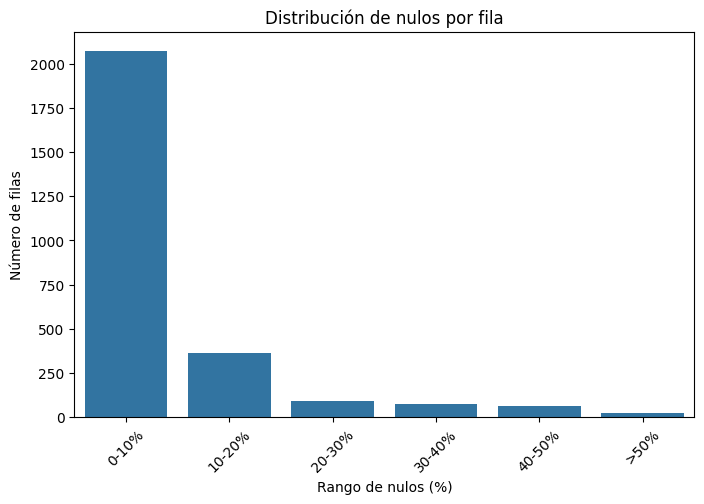


Número de filas con más de 30% de nulos: 160


In [9]:

# 1. Porcentaje de nulos por fila
df_null_rows = df.isnull().mean(axis=1) * 100

# Convertimos a DataFrame para trabajar mejor
df_null_rows = df_null_rows.to_frame(name='porcentaje_nulos')

# 2. Clasificación en rangos (MISMA lógica que columnas)
bins = [0, 10, 20, 30, 40, 50, 100]
labels = ['0-10%', '10-20%', '20-30%', '30-40%', '40-50%', '>50%']

df_null_rows['rango_nulos'] = pd.cut(df_null_rows['porcentaje_nulos'], bins=bins, labels=labels, include_lowest=True)

# 3. Conteo por rango
conteo_filas = df_null_rows['rango_nulos'].value_counts().sort_index()

print("Distribución de filas según porcentaje de nulos:\n")
print(conteo_filas)

# 4. Visualización
plt.figure(figsize=(8,5))
sns.barplot(x=conteo_filas.index, y=conteo_filas.values)
plt.title("Distribución de nulos por fila")
plt.xlabel("Rango de nulos (%)")
plt.ylabel("Número de filas")
plt.xticks(rotation=45)
plt.show()

# 5. Filas problemáticas (>30%)
filas_malas = df_null_rows[df_null_rows['porcentaje_nulos'] > 30]

print(f"\nNúmero de filas con más de 30% de nulos: {len(filas_malas)}")

La mayor parte de nuestros pacientes presentan un porcentage de nulos ínfimo (0-10%). Para evitar perder un gran volumen de pacientes, vamos a proceder a eliminar únicamente aquellos cuyo porcentage de nulos sea superior al 30%

In [10]:
# 1. Filtrar filas con <=30% de nulos
df_clean_rows = df[df_null_rows['porcentaje_nulos'] <= 30].copy()

# 2. Comparación antes vs después
print("ANTES:")
print(f"Filas: {df.shape[0]}")
print(f"Columnas: {df.shape[1]}")

print("\nDESPUÉS (filtrando >30% nulos):")
print(f"Filas: {df_clean_rows.shape[0]}")
print(f"Columnas: {df_clean_rows.shape[1]}")

# 3. Filas eliminadas
filas_eliminadas = df.shape[0] - df_clean_rows.shape[0]
print(f"\nFilas eliminadas: {filas_eliminadas}")

ANTES:
Filas: 2687
Columnas: 124

DESPUÉS (filtrando >30% nulos):
Filas: 2527
Columnas: 124

Filas eliminadas: 160


In [ ]:
# Cálculo de porcentajes de nulos
null_counts = df_clean_rows.isnull().sum()
null_percentages = (null_counts / len(df_clean_rows)) * 100

# Tabla resumen de nulos
df_nulls = pd.DataFrame({
    'Variable': null_percentages.index,
    'Porcentaje_Nulos': null_percentages.values
}).sort_values(by='Porcentaje_Nulos', ascending=False)

# Clasificación por rangos 
bins = [0, 10, 20, 30, 100]
labels = ['0-10%', '10-20%', '20-30%', '>30%']

# Creamos una columna de rango 
df_nulls['Rango'] = pd.cut(df_nulls['Porcentaje_Nulos'], bins=bins, labels=labels, include_lowest=True)

# Mostrar conteo de variables por rango
resumen_rangos = df_nulls['Rango'].value_counts().sort_index()

print("--- Resumen de Variables por Rango de Nulos ---")
for rango, cantidad in resumen_rangos.items():
    print(f"Rango {rango}: {cantidad} variables")

# Mostrar las variables con más nulos 
print("\nPorcentage de nulos por variable")
print(df_nulls.to_string(index=False))
#TODO: Comentar!!

--- Resumen de Variables por Rango de Nulos ---
Rango 0-10%: 105 variables
Rango 10-20%: 13 variables
Rango 20-30%: 6 variables
Rango >30%: 0 variables

Porcentage de nulos por variable
          Variable  Porcentaje_Nulos  Rango
  med_osteoporosis         25.207756 20-30%
     test_densidad         23.031262 20-30%
     uso_anticidos         21.250495 20-30%
   total_anticidos         21.250495 20-30%
 total_suplementos         21.052632 20-30%
   uso_suplementos         21.052632 20-30%
     romberg_4_seg         17.768104 10-20%
     romberg_4_res         17.609814 10-20%
     romberg_3_seg         17.253660 10-20%
     romberg_3_res         17.055797 10-20%
     romberg_2_seg         16.224772 10-20%
     romberg_2_res         16.185200 10-20%
     romberg_1_seg         16.066482 10-20%
     romberg_1_res         16.026909 10-20%
 diag_osteoporosis         15.670756 10-20%
         fracturas         15.552038 10-20%
             cadas         14.602295 10-20%
dificultad_caminar    

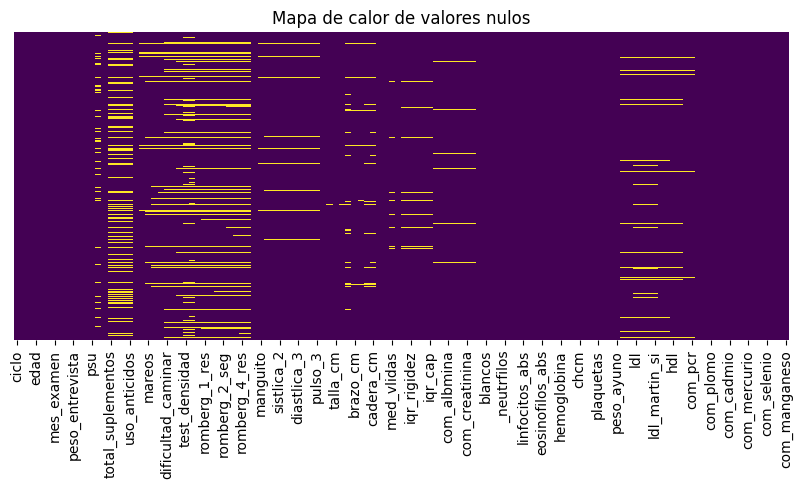

In [12]:
# Visualización rápida de nulos
plt.figure(figsize=(10, 4))
sns.heatmap(df_clean_rows.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title('Mapa de calor de valores nulos')
plt.show()

## Distribuciones y Outliers (Numéricas)

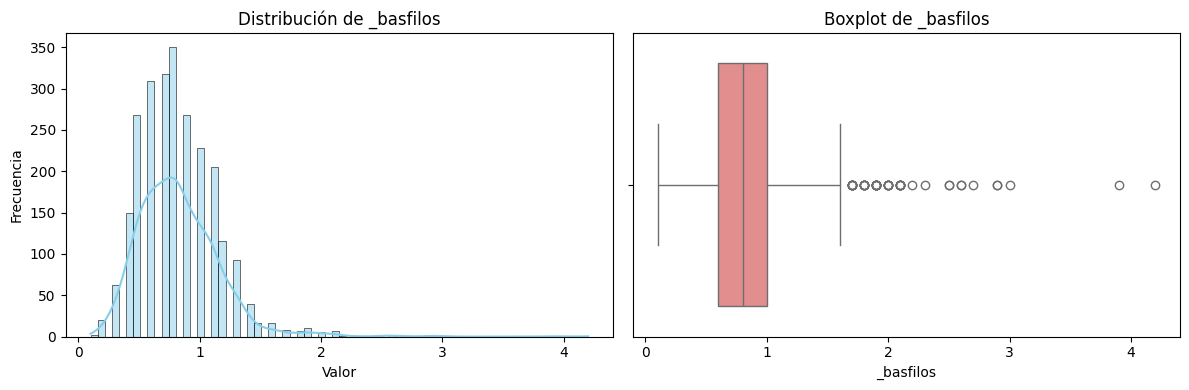

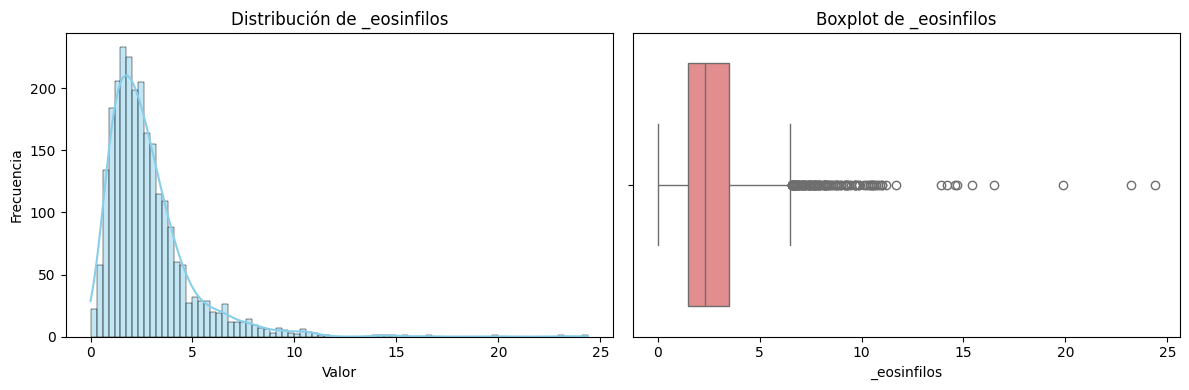

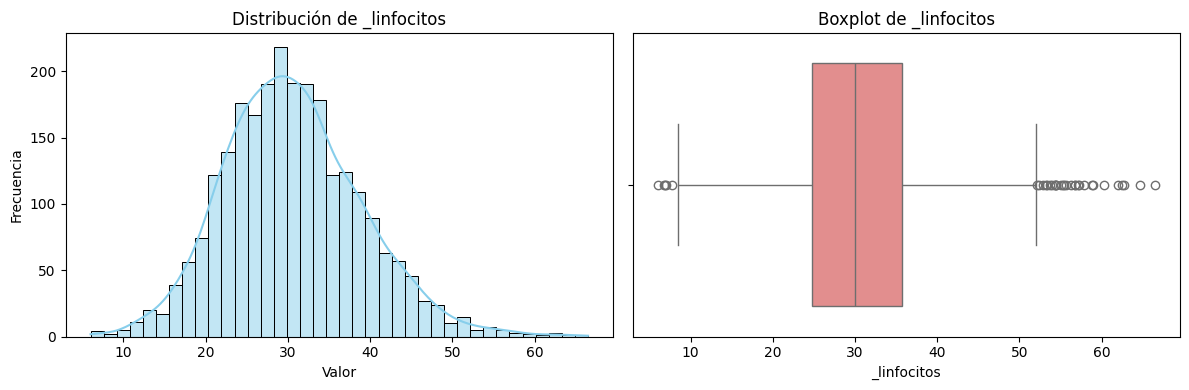

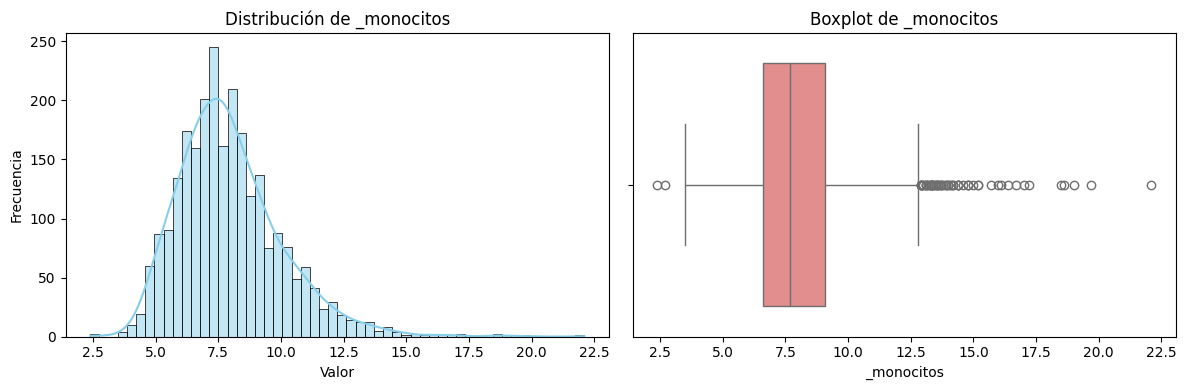

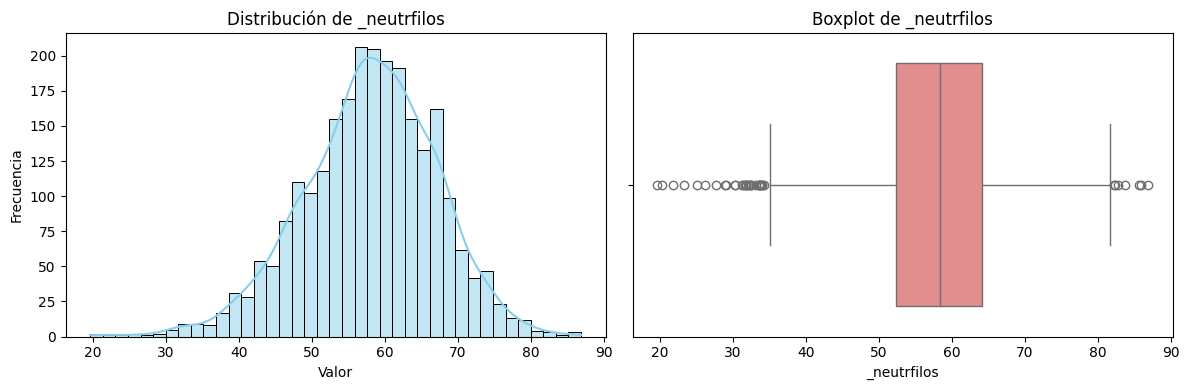

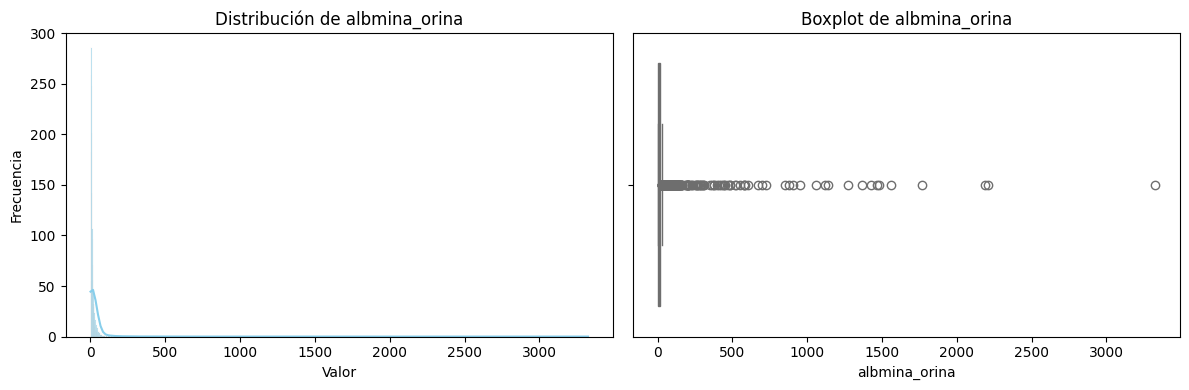

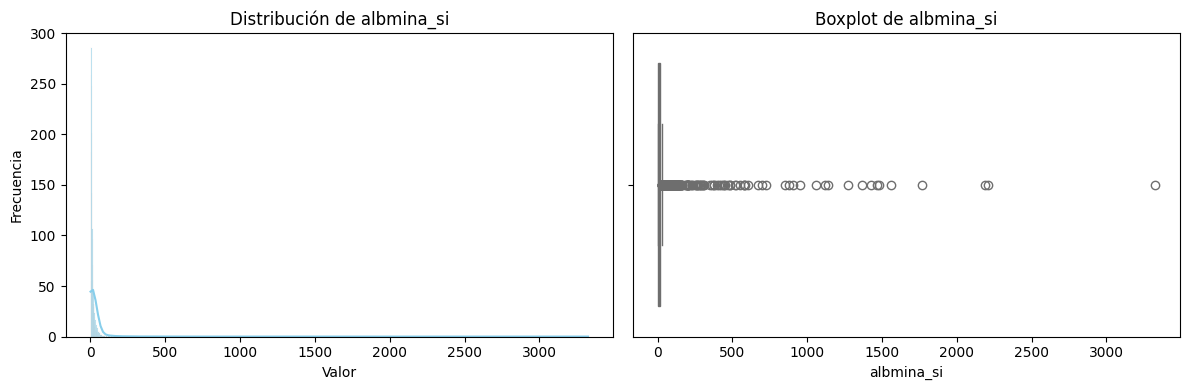

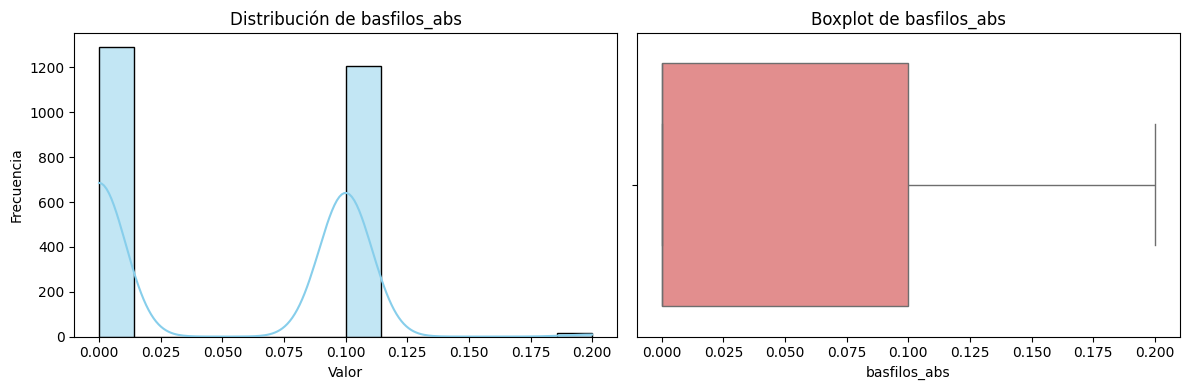

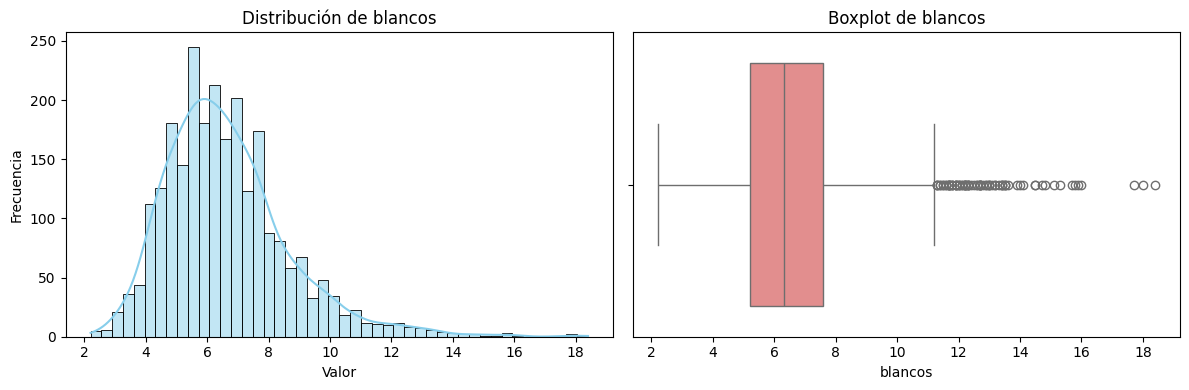

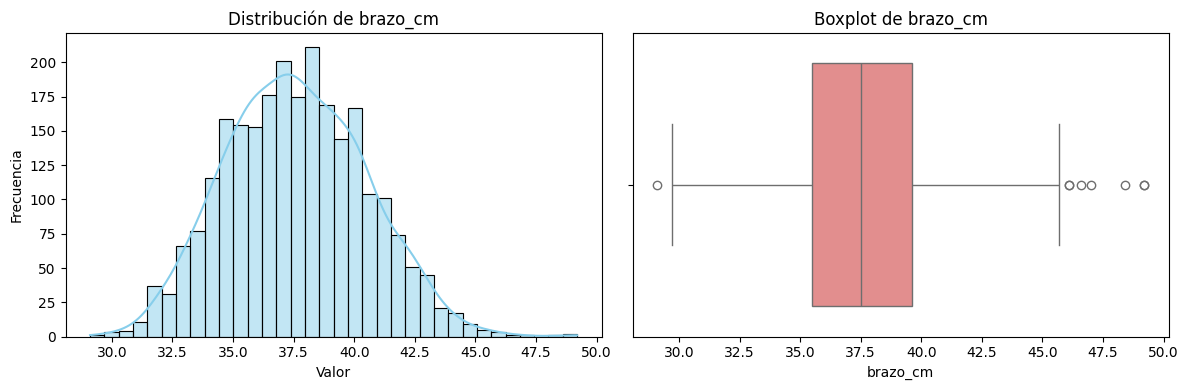

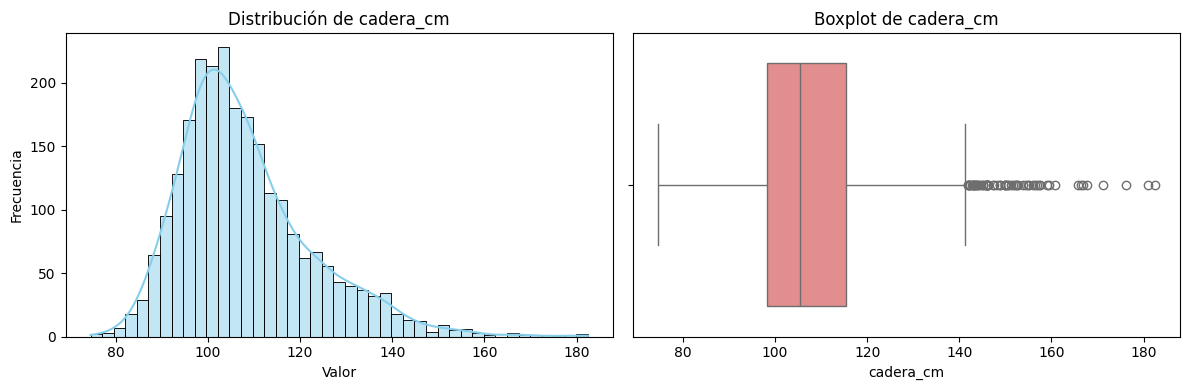

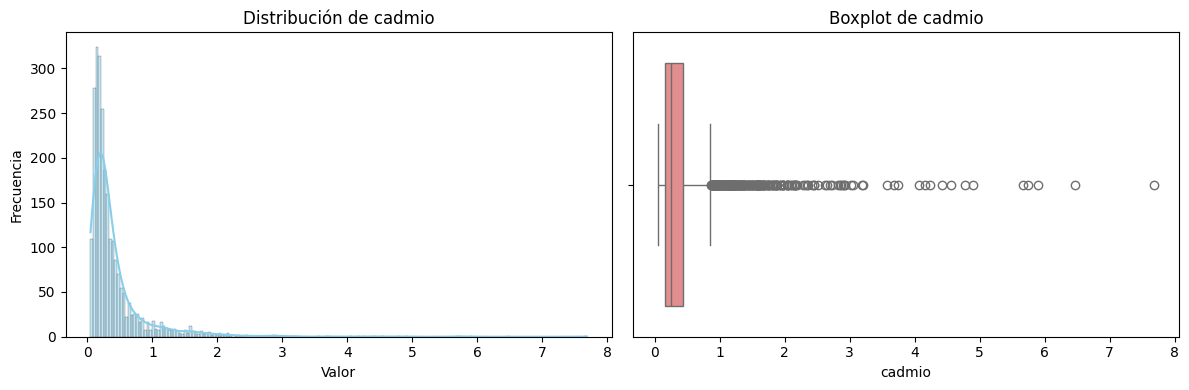

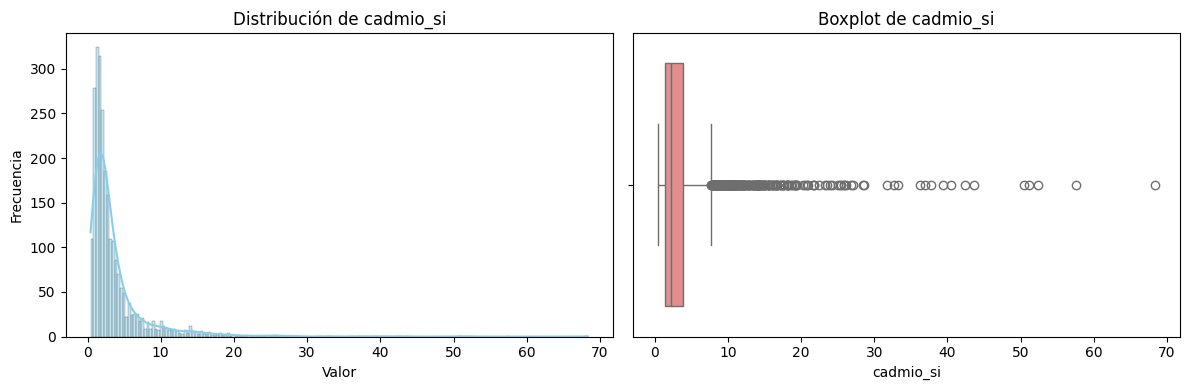

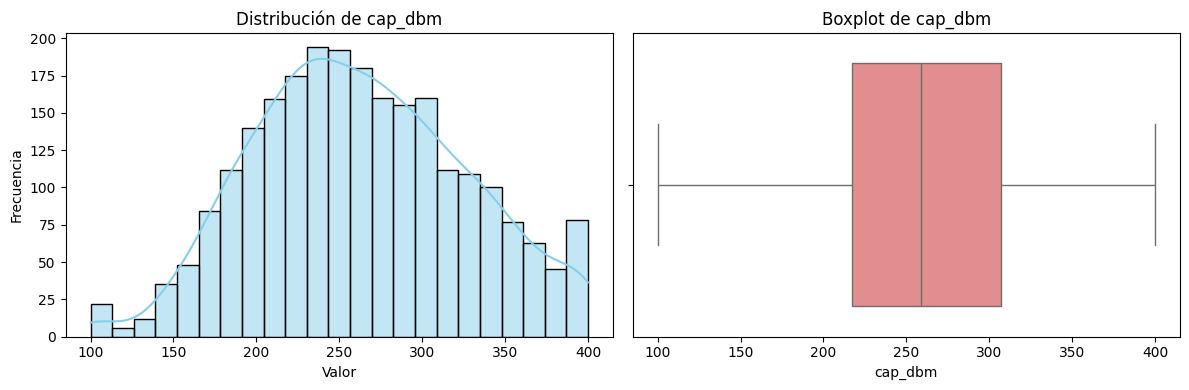

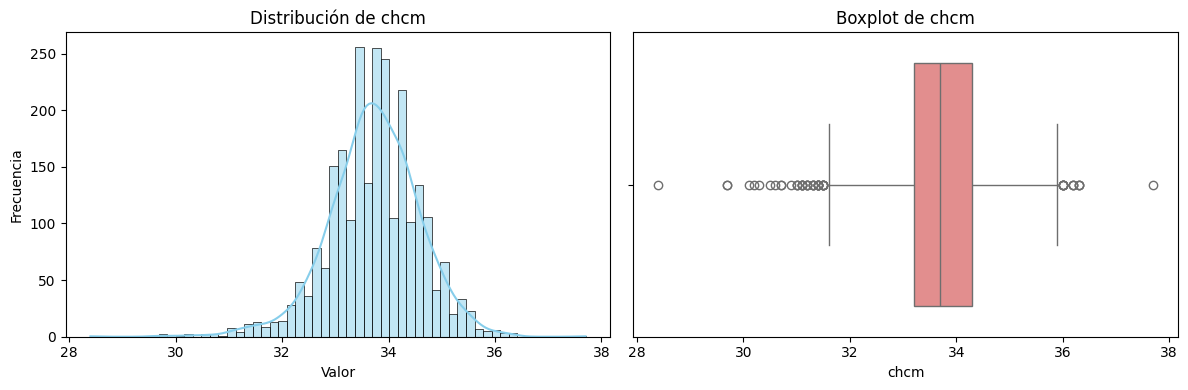

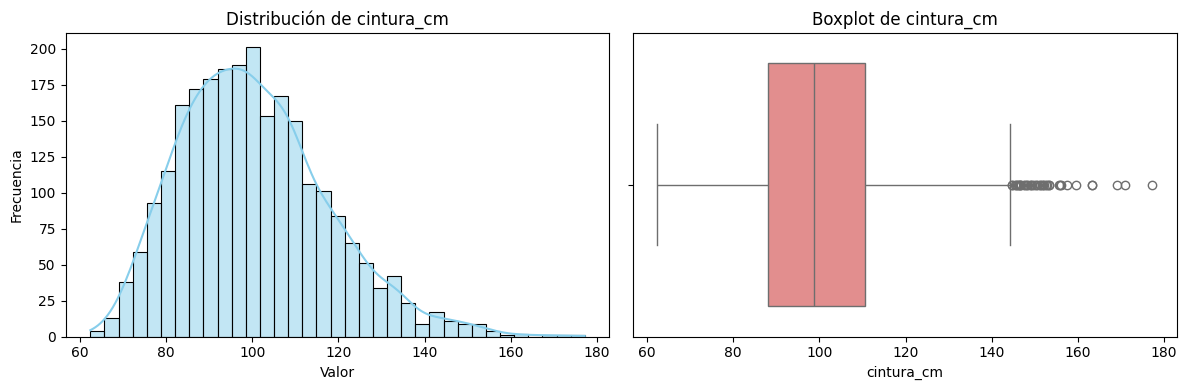

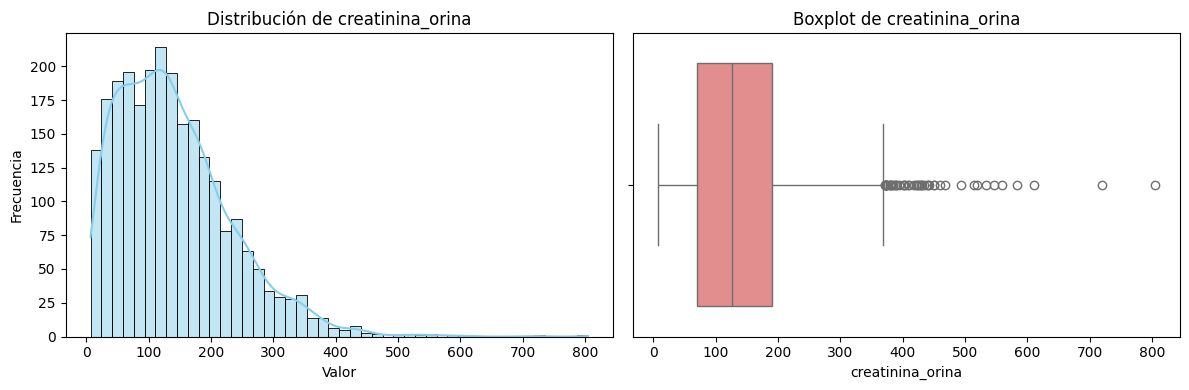

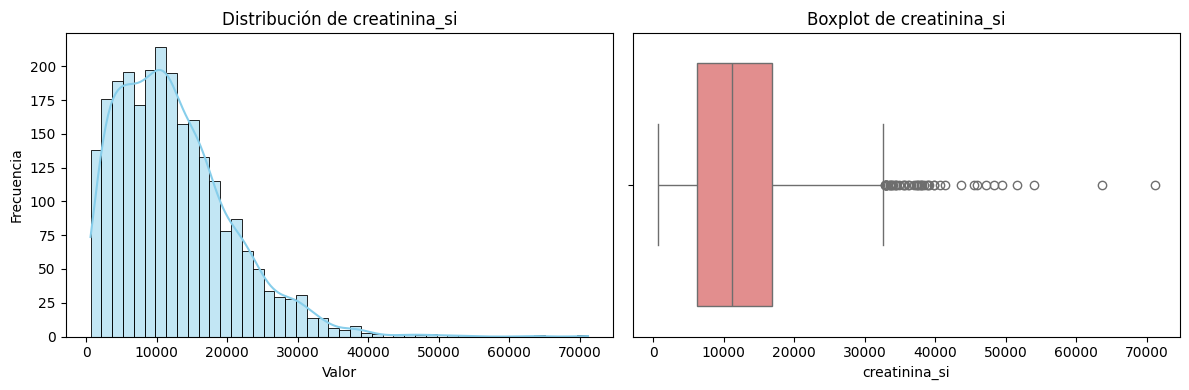

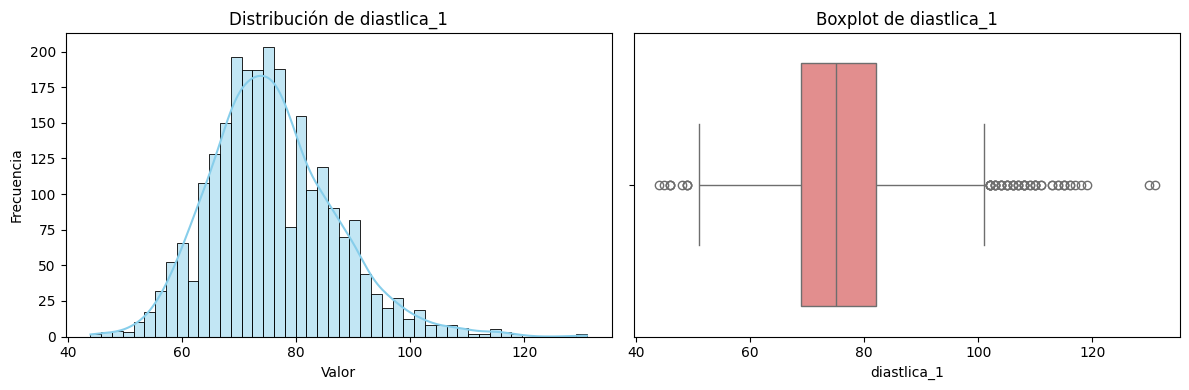

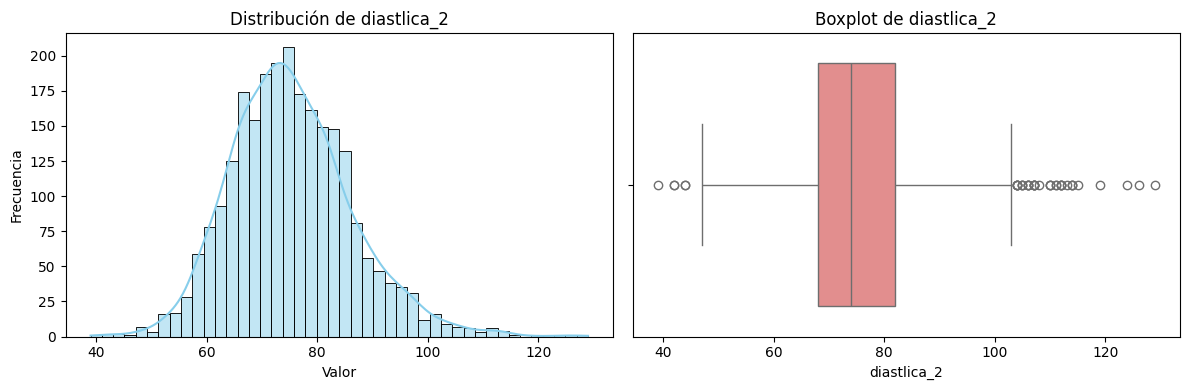

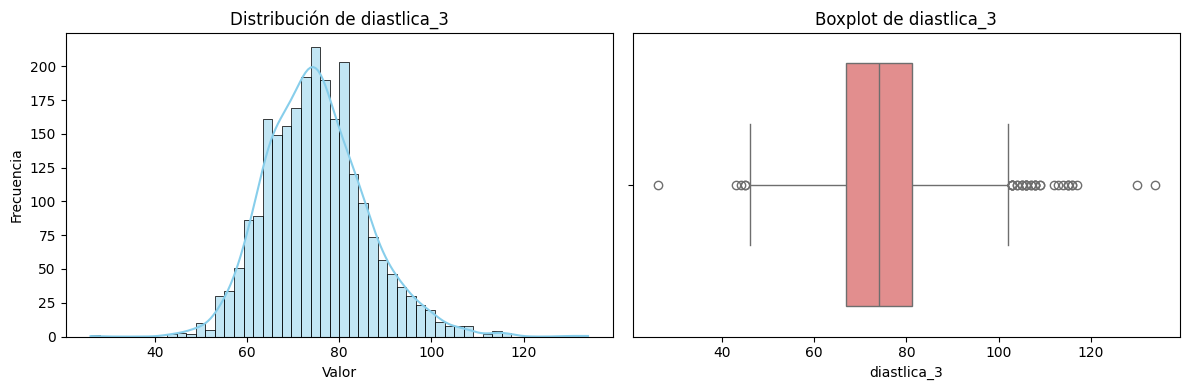

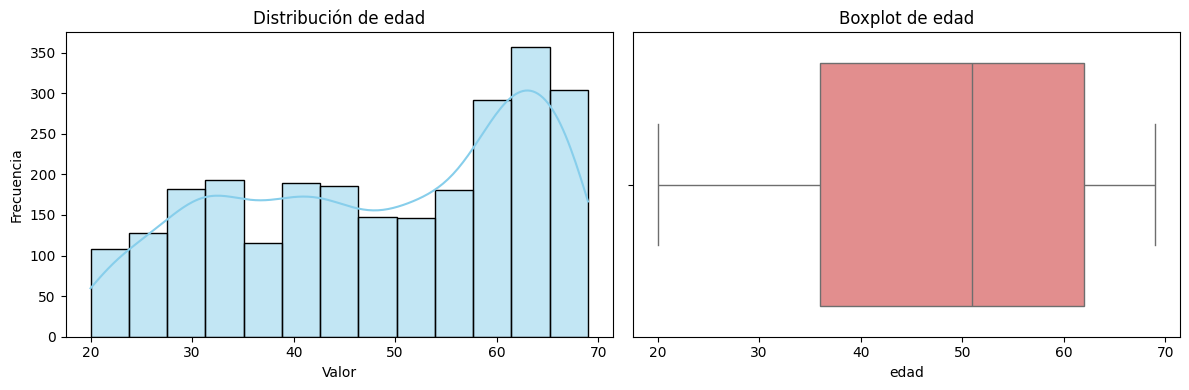

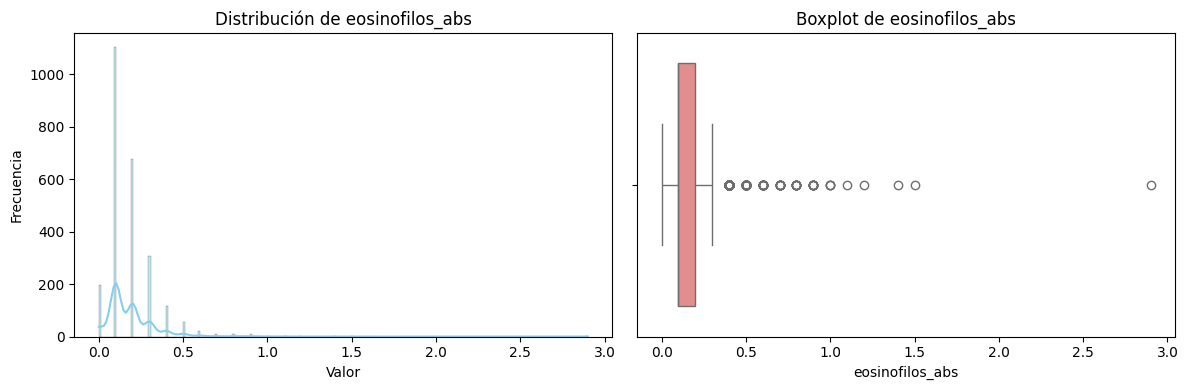

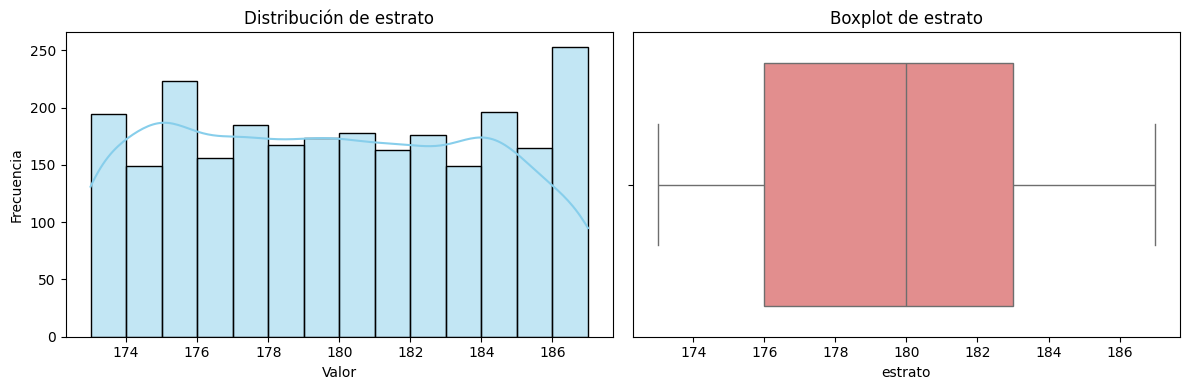

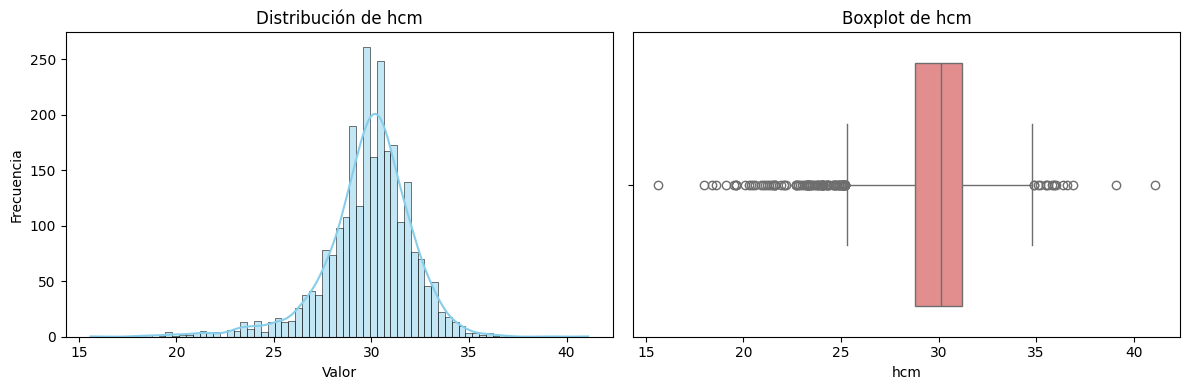

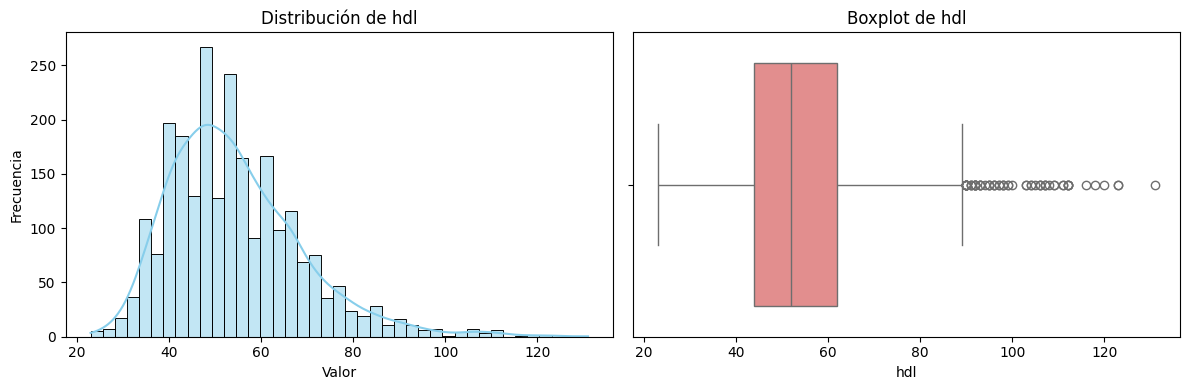

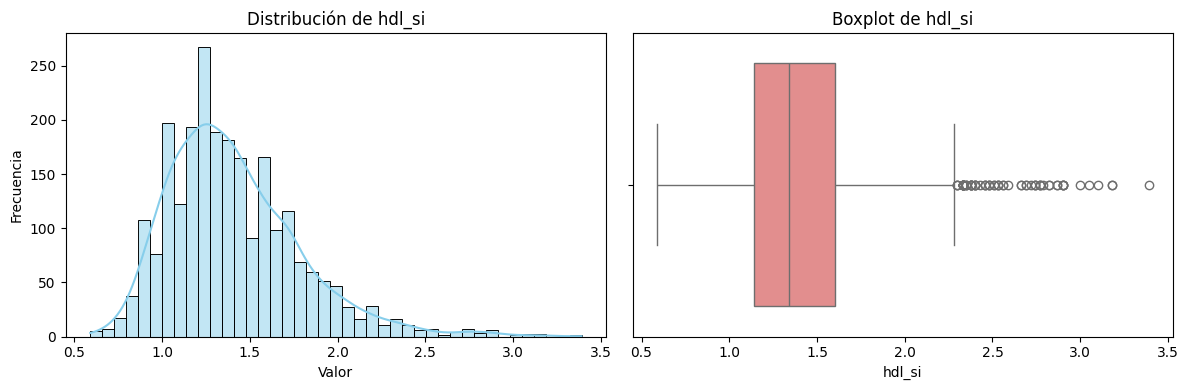

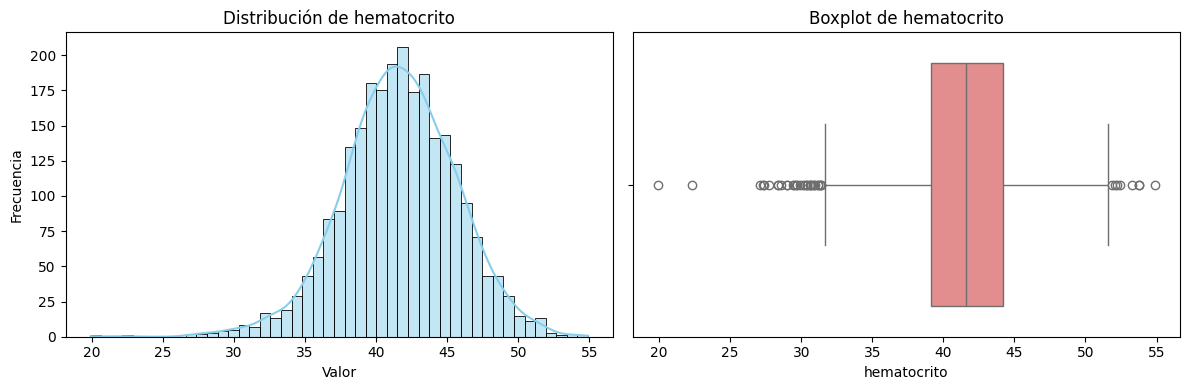

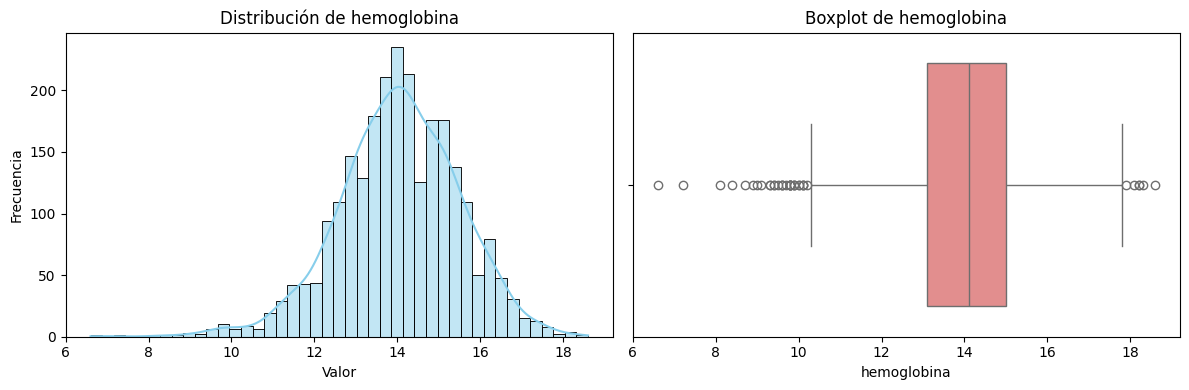

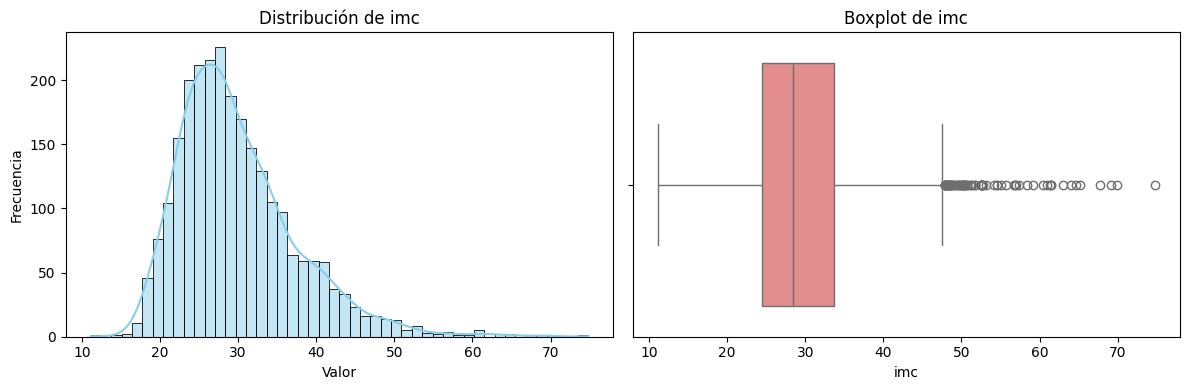

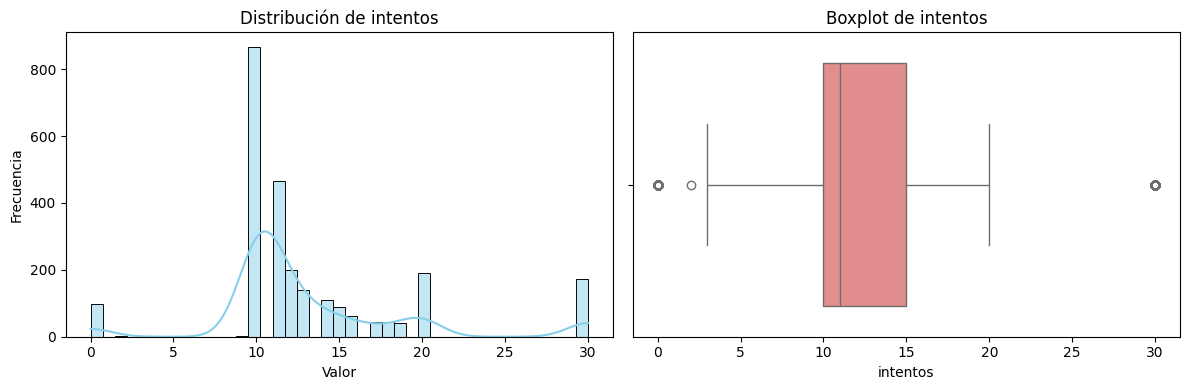

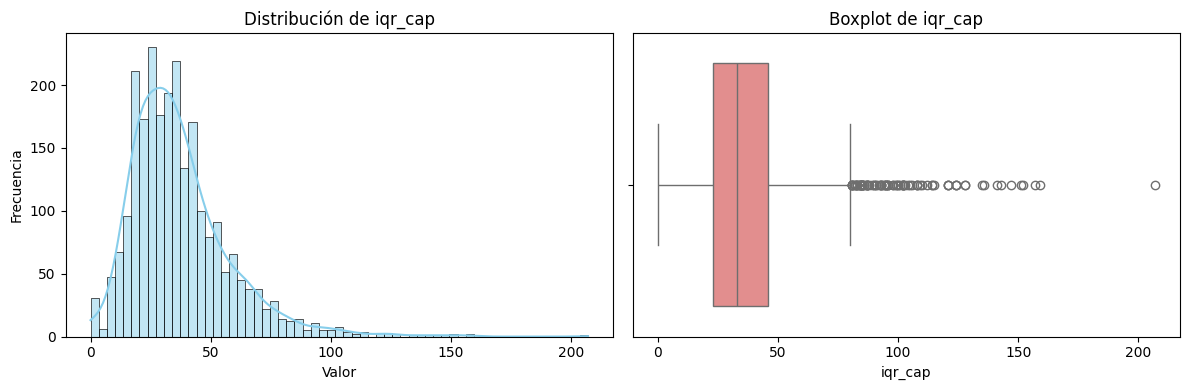

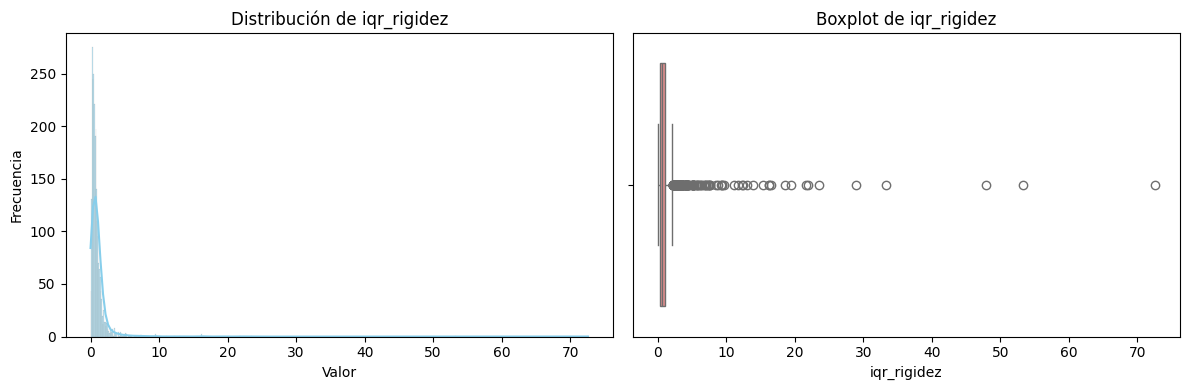

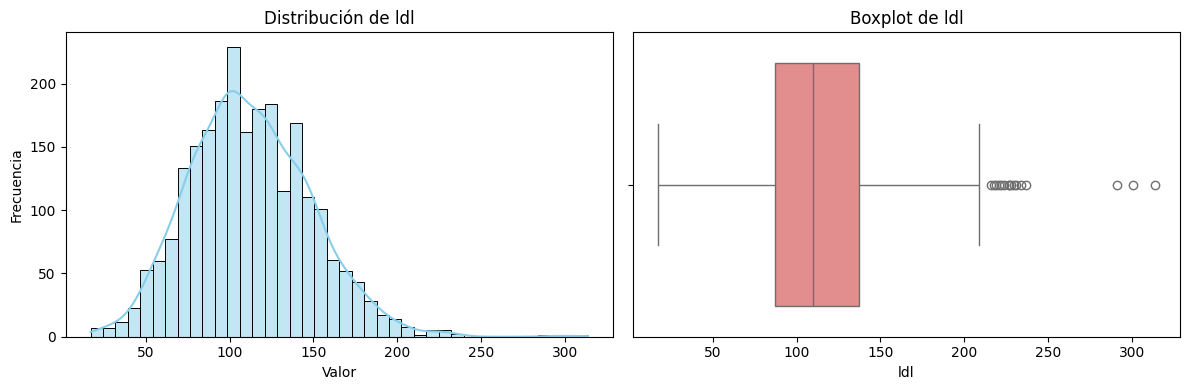

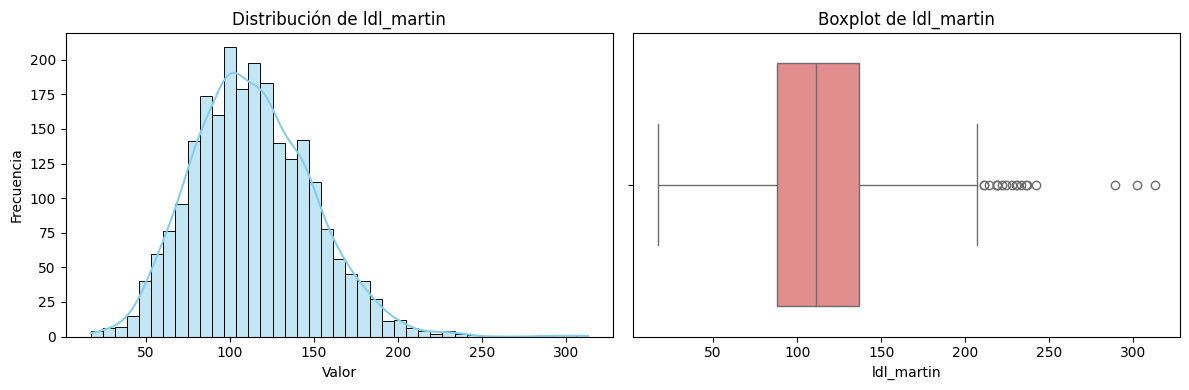

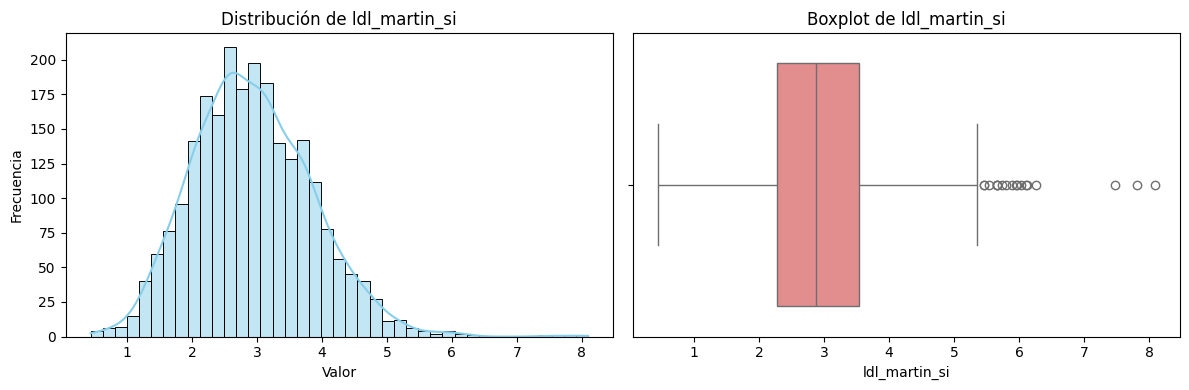

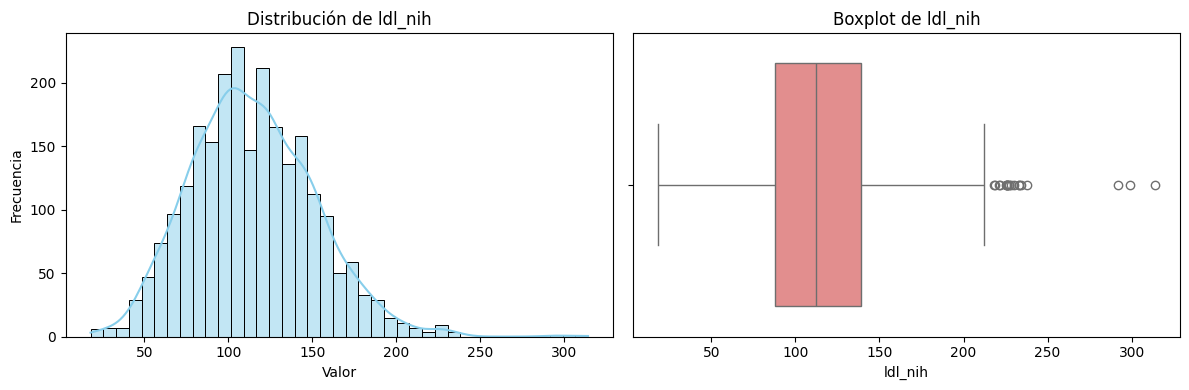

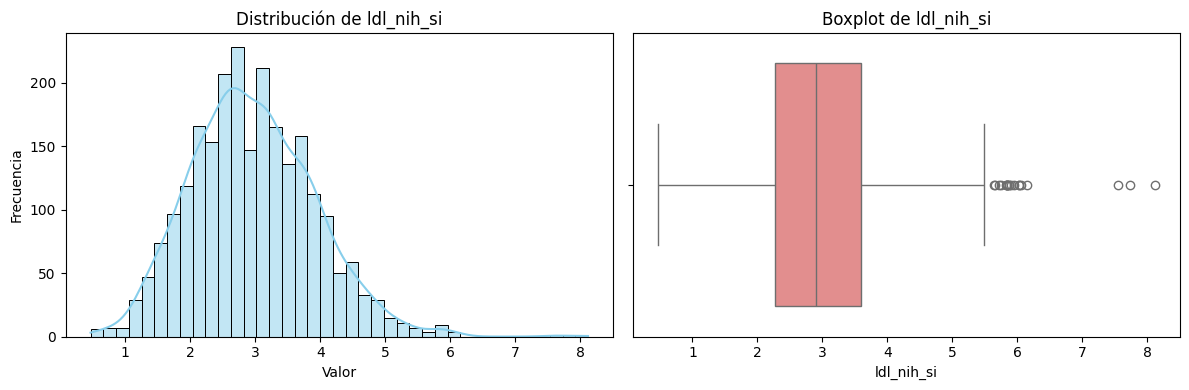

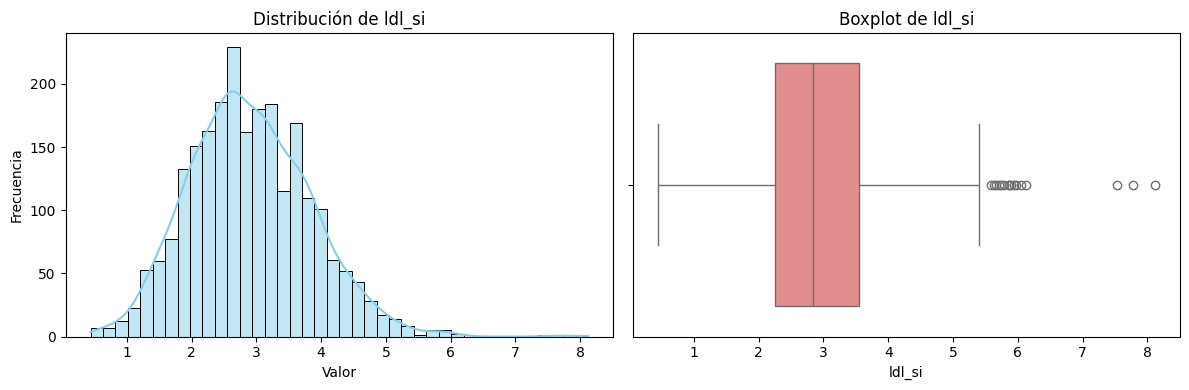

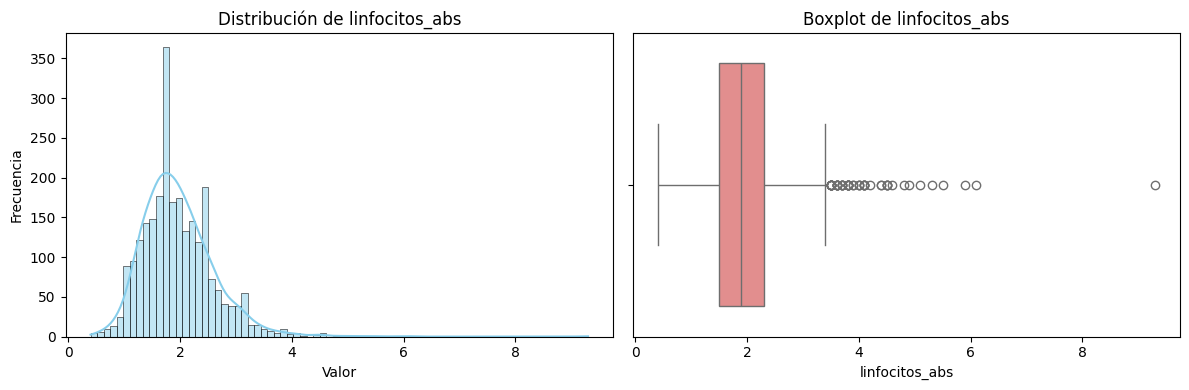

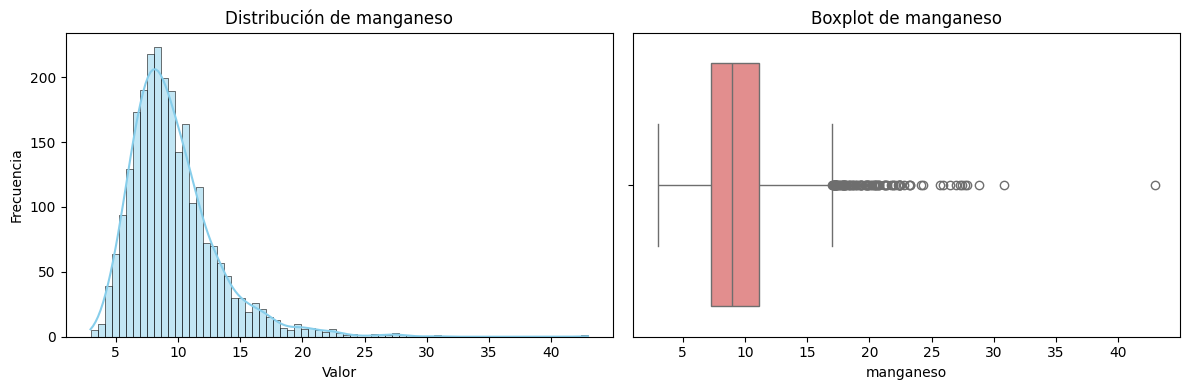

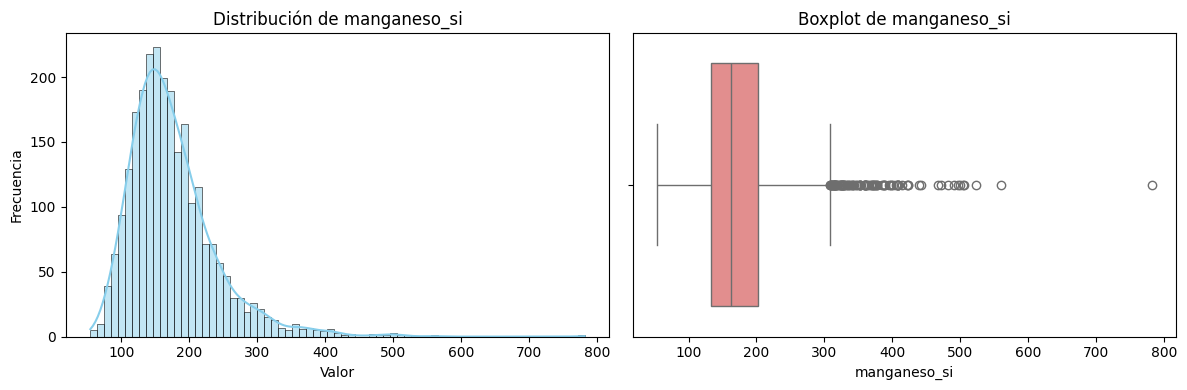

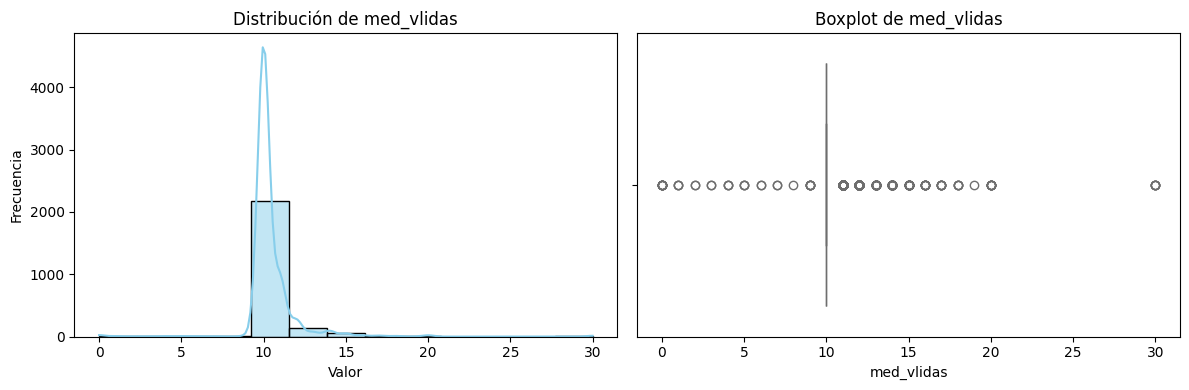

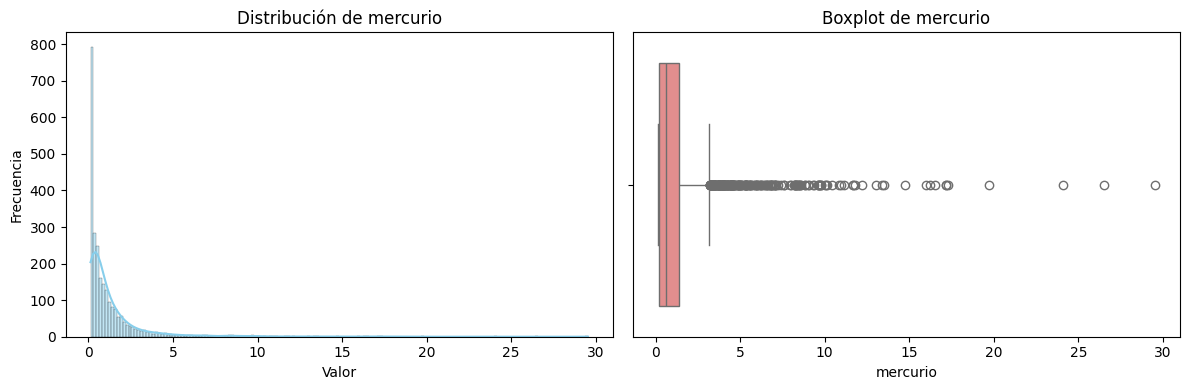

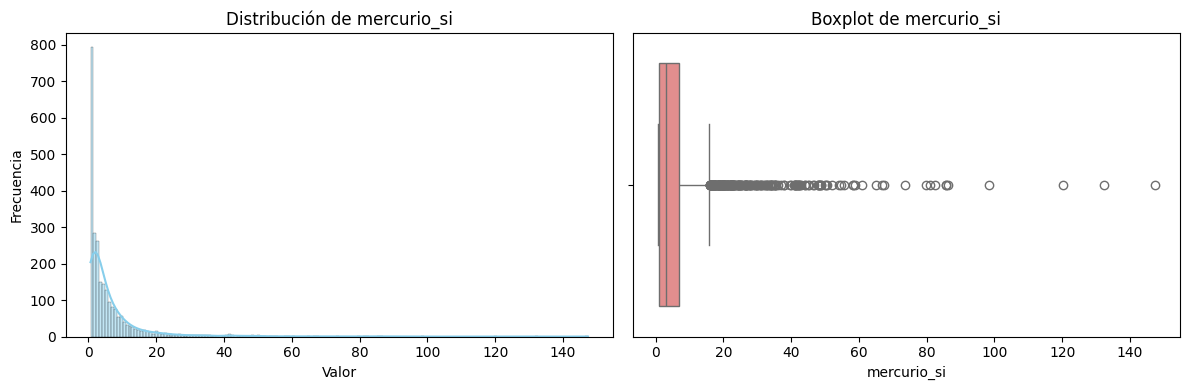

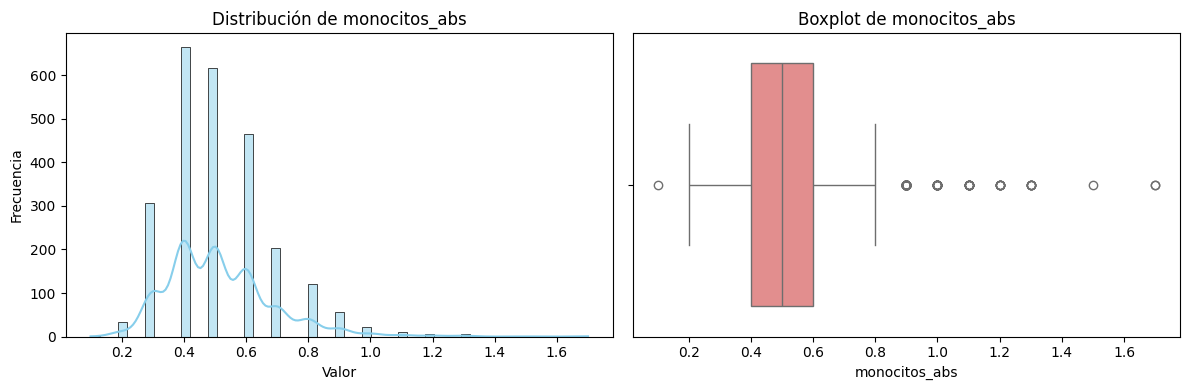

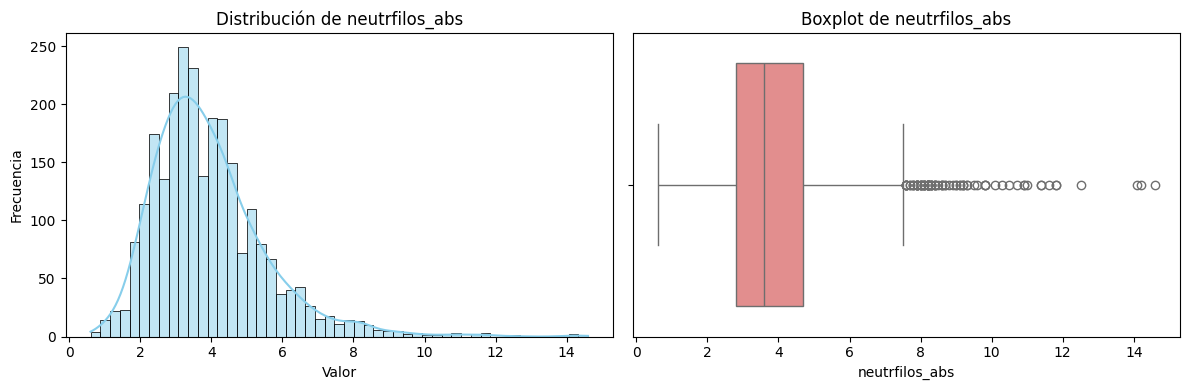

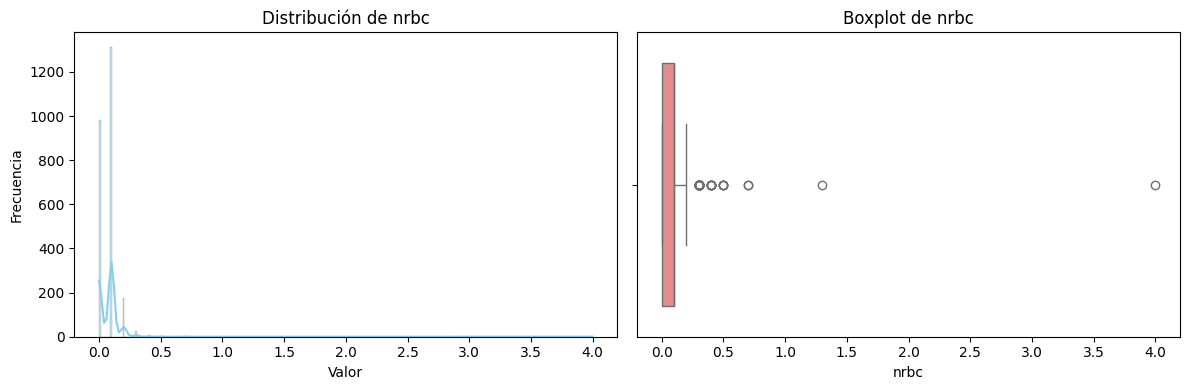

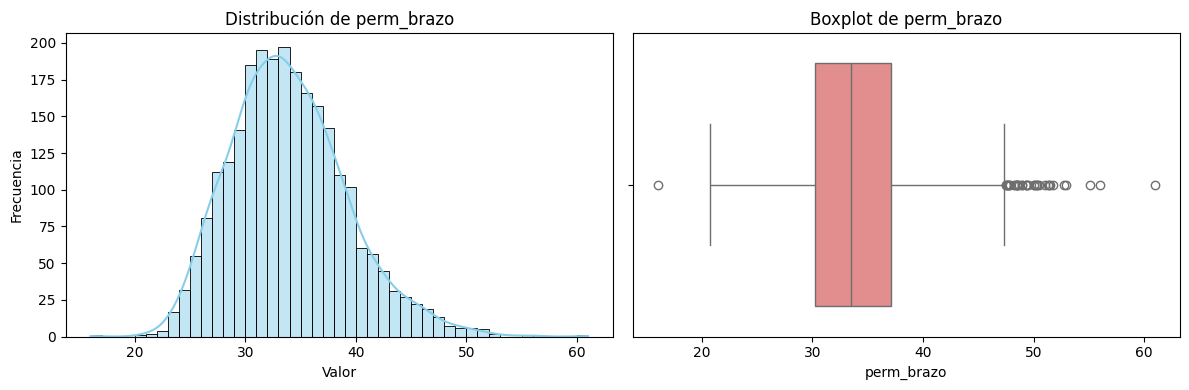

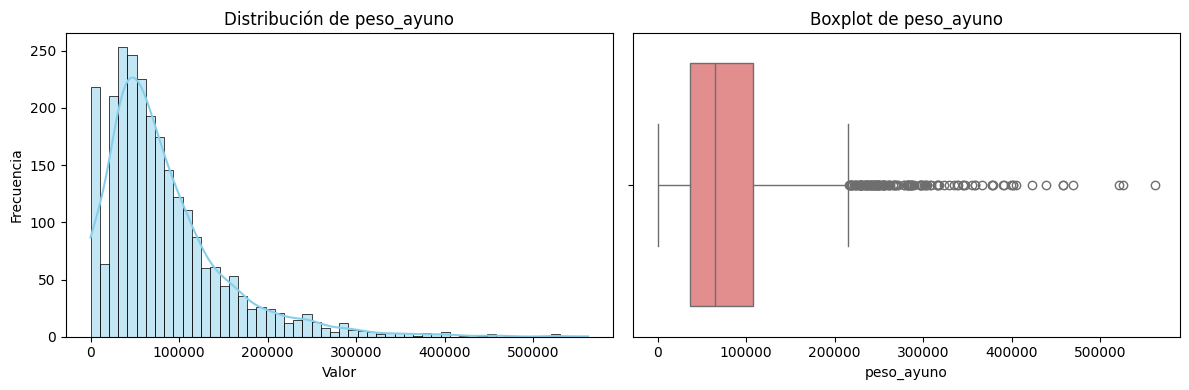

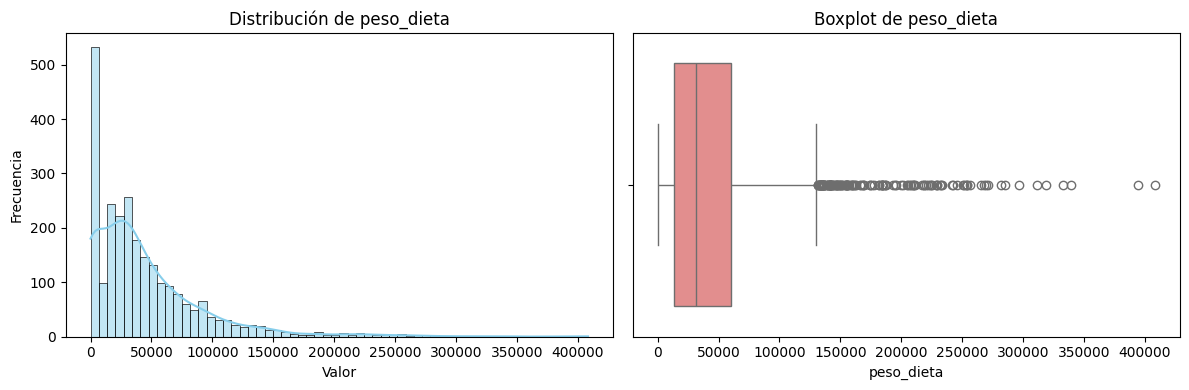

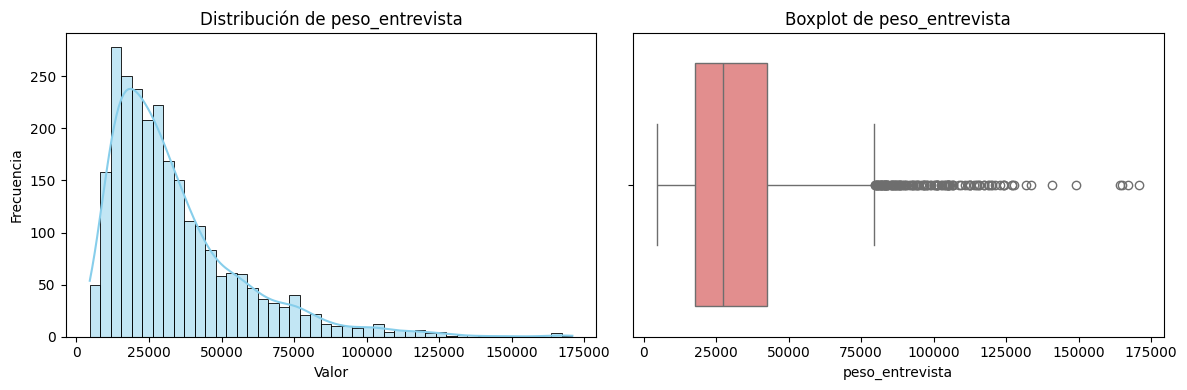

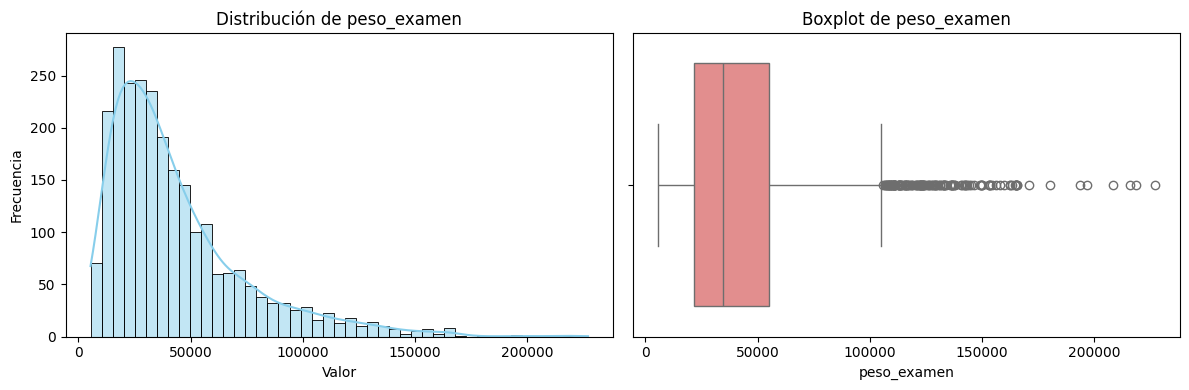

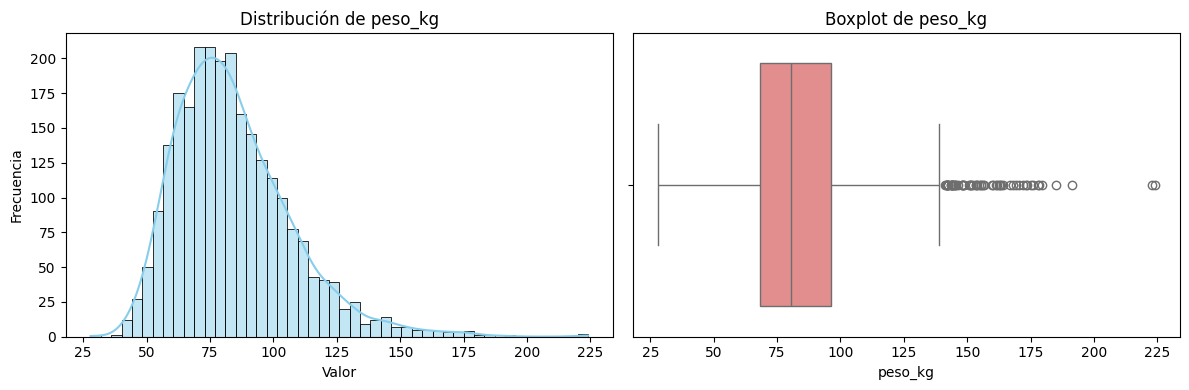

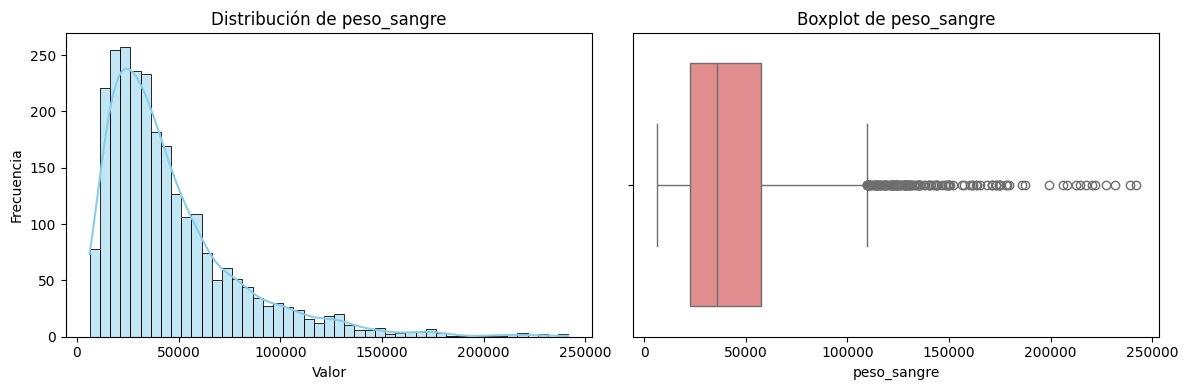

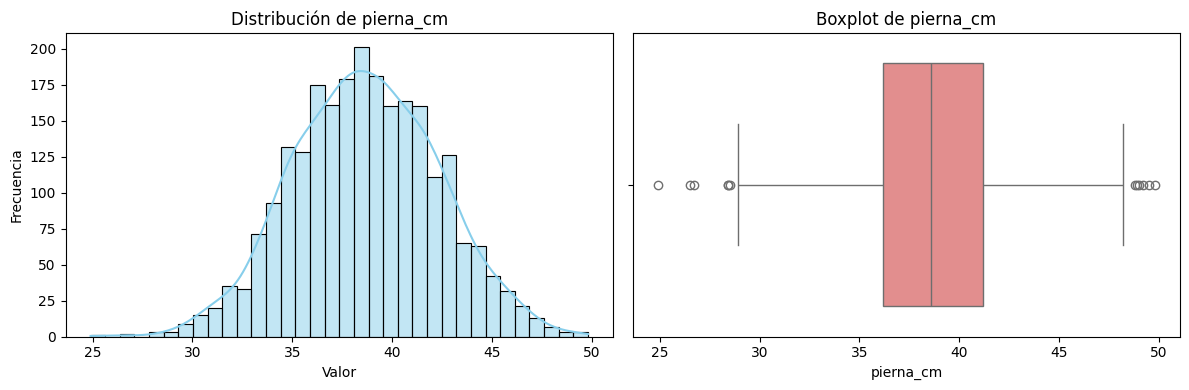

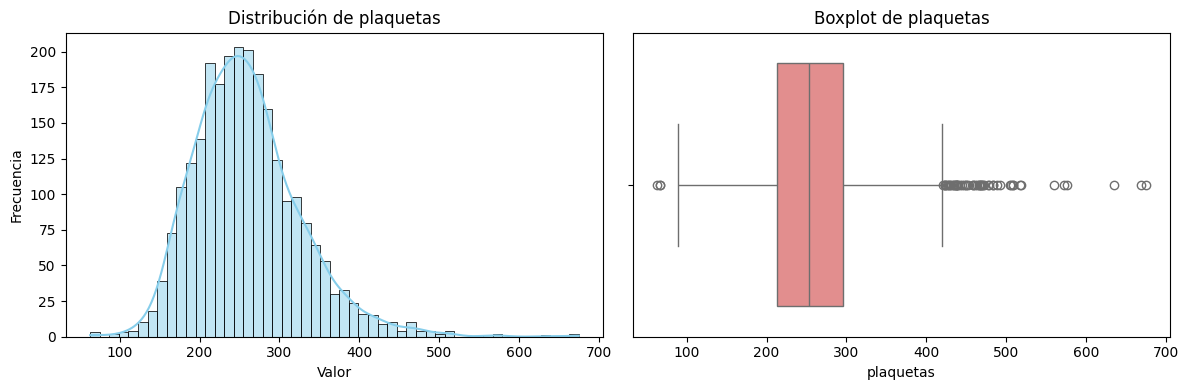

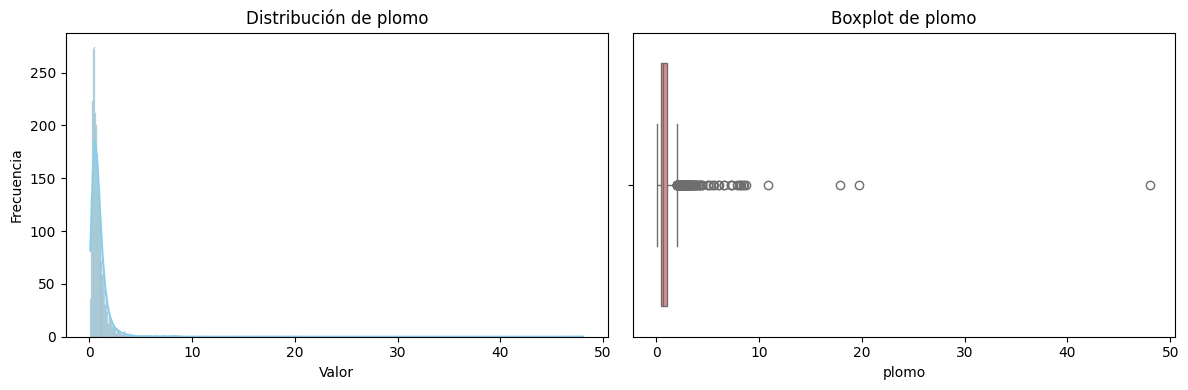

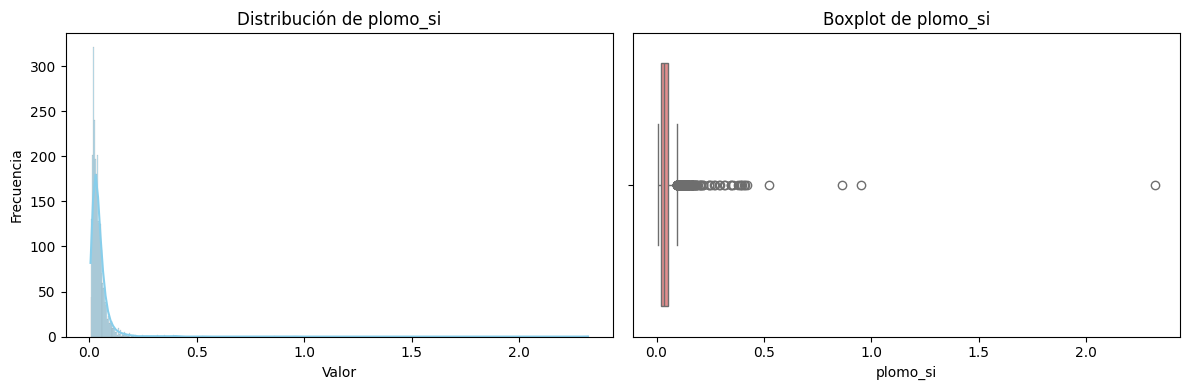

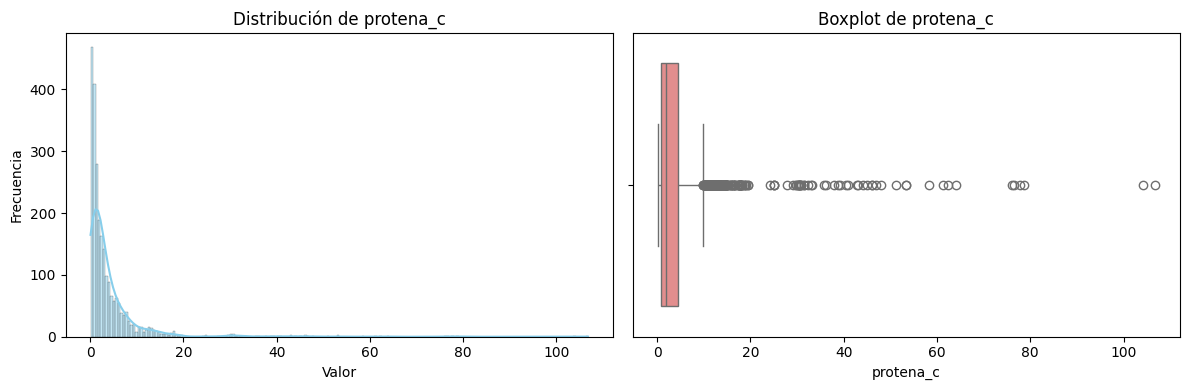

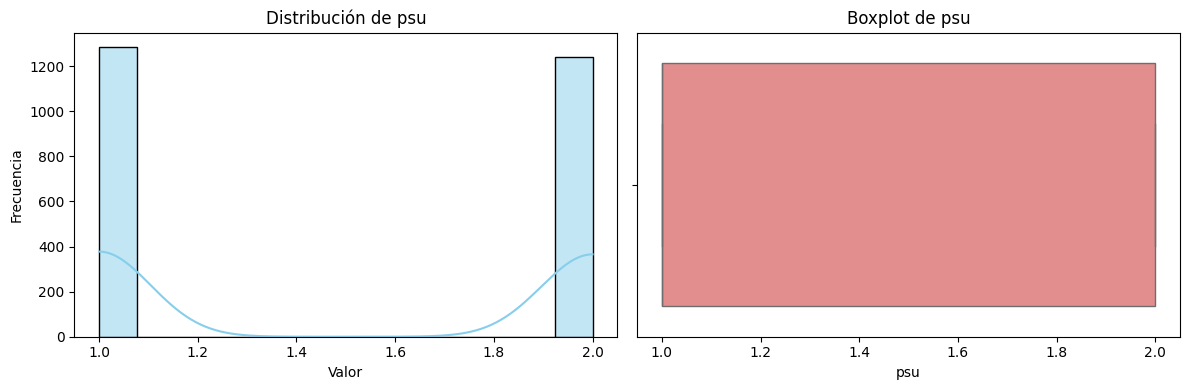

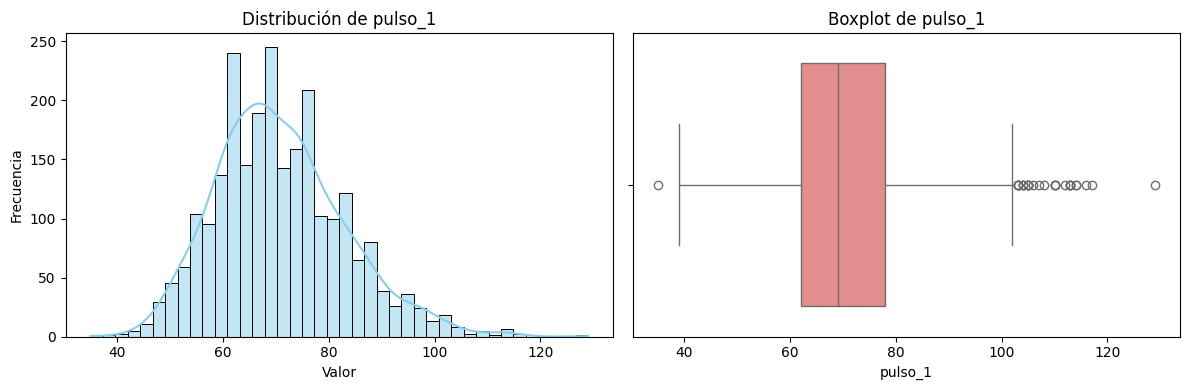

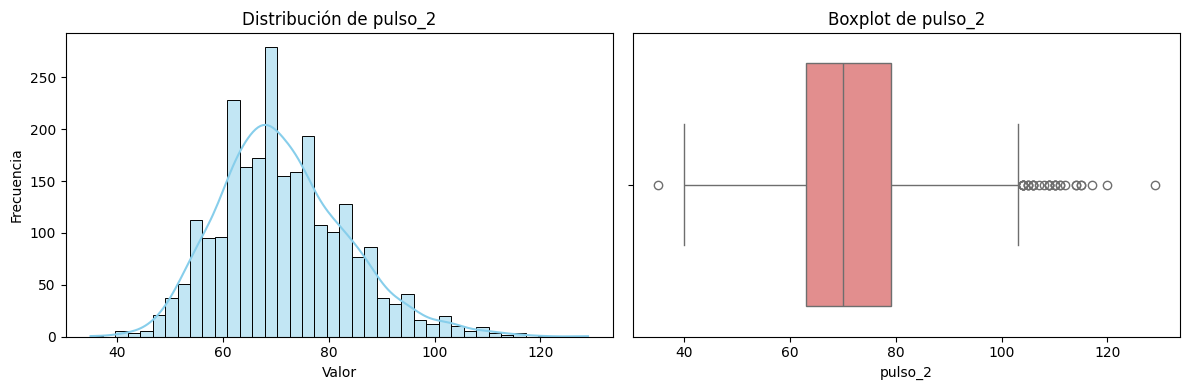

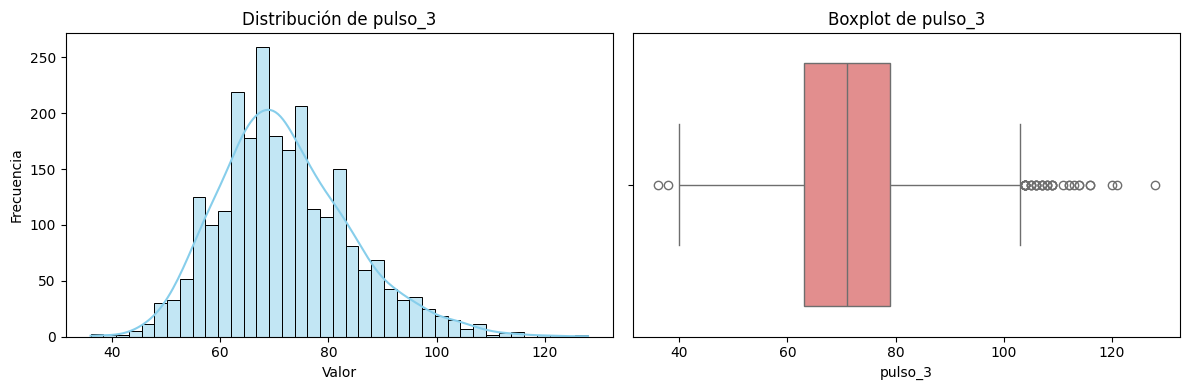

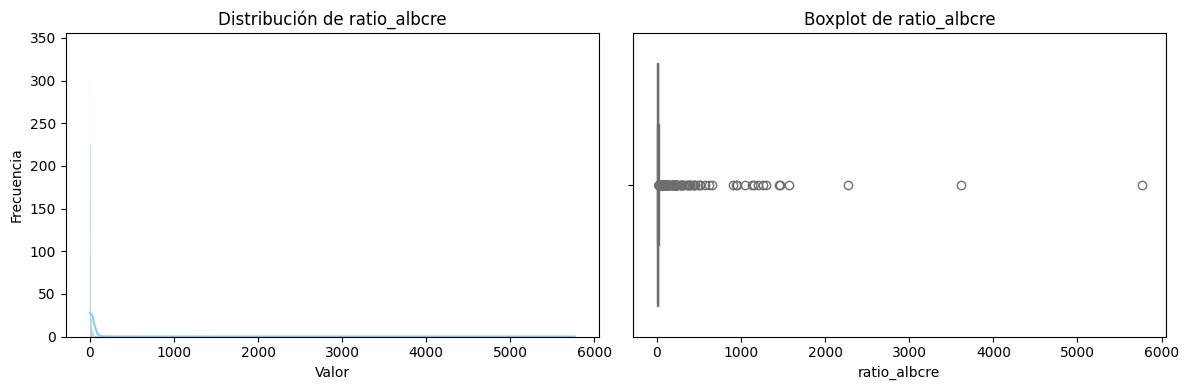

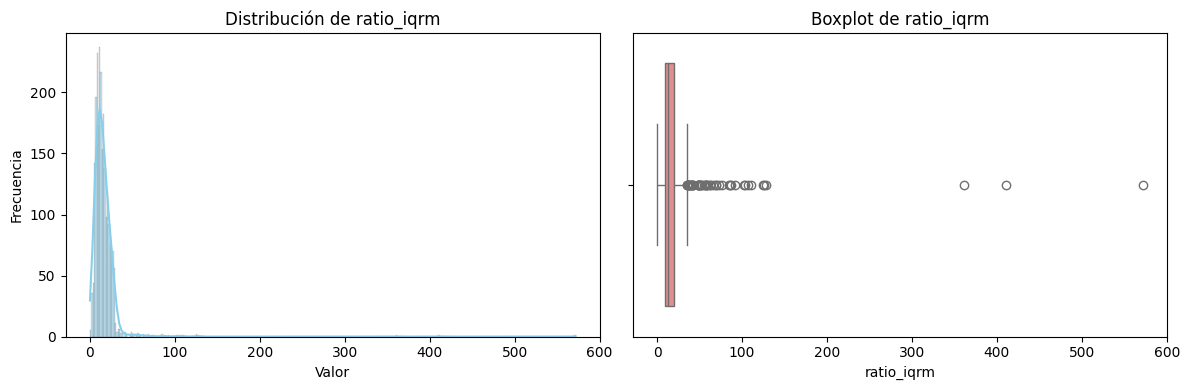

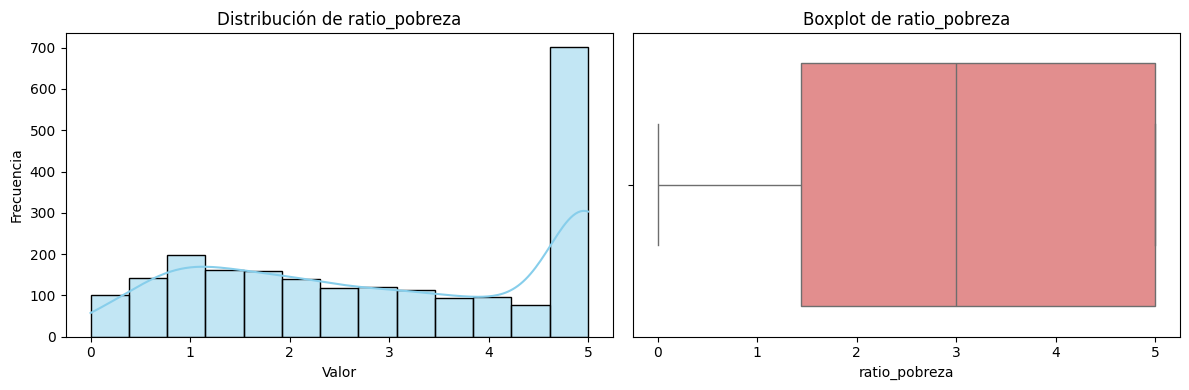

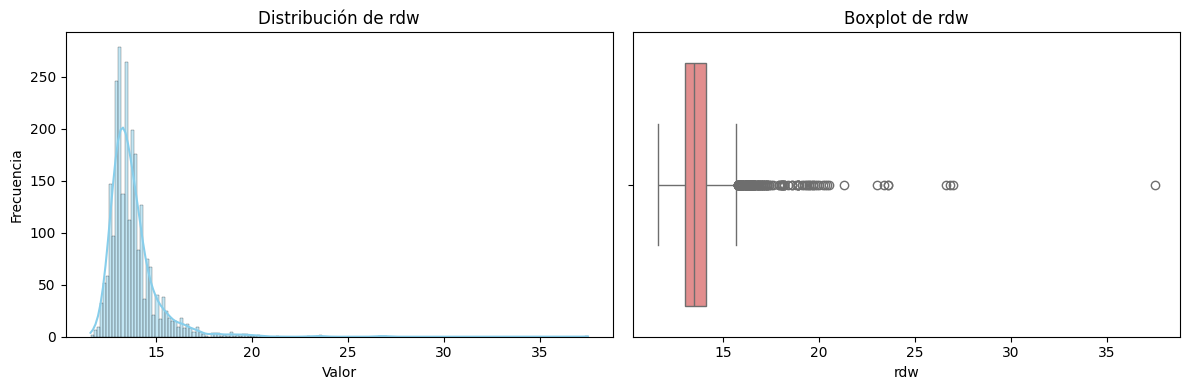

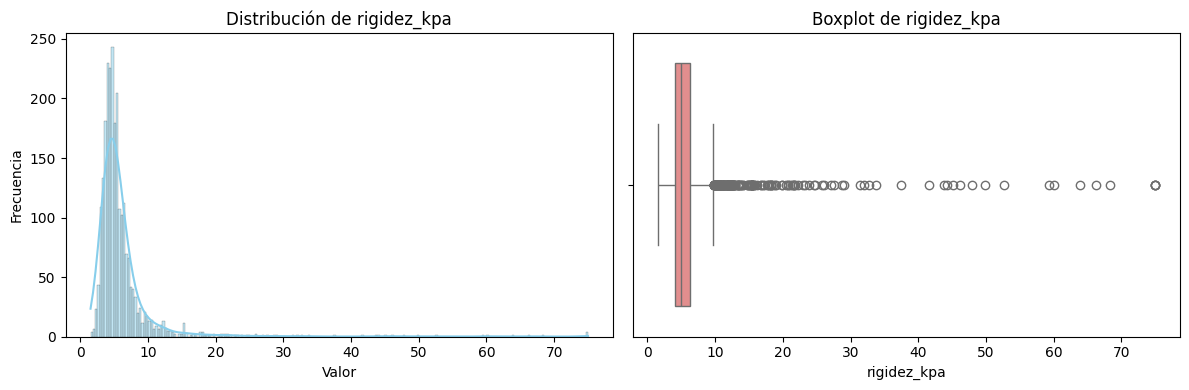

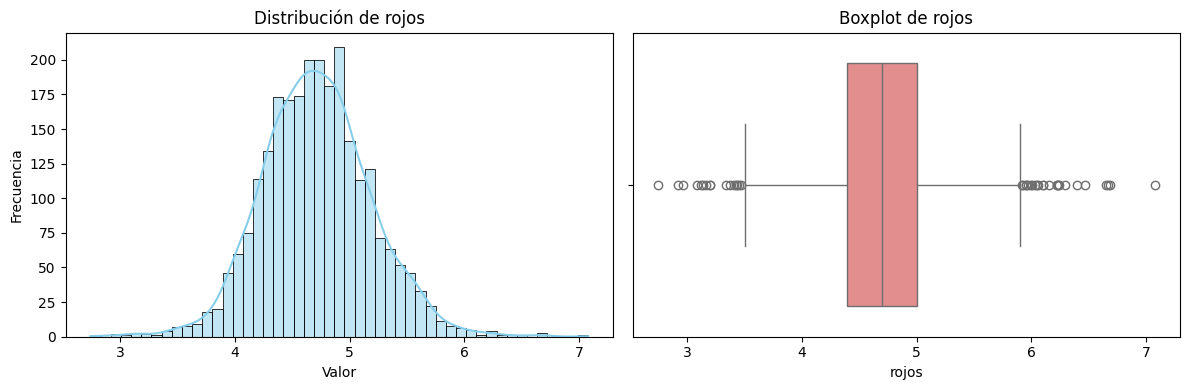

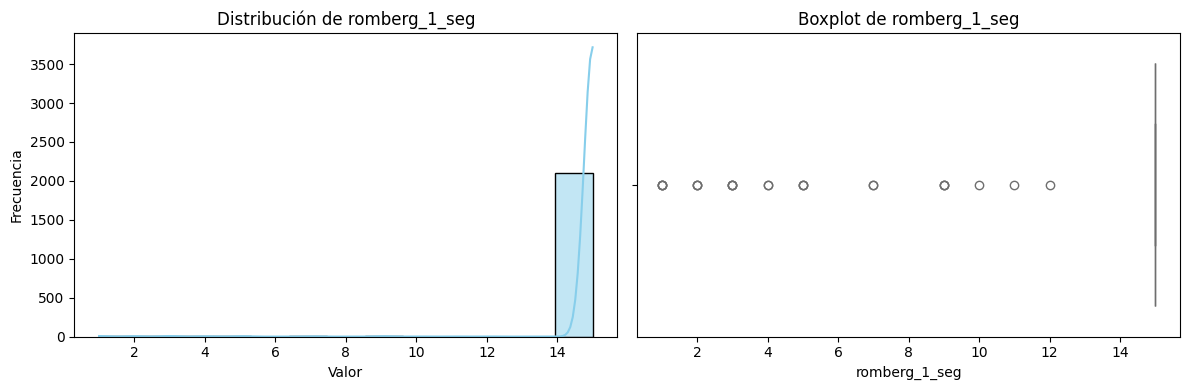

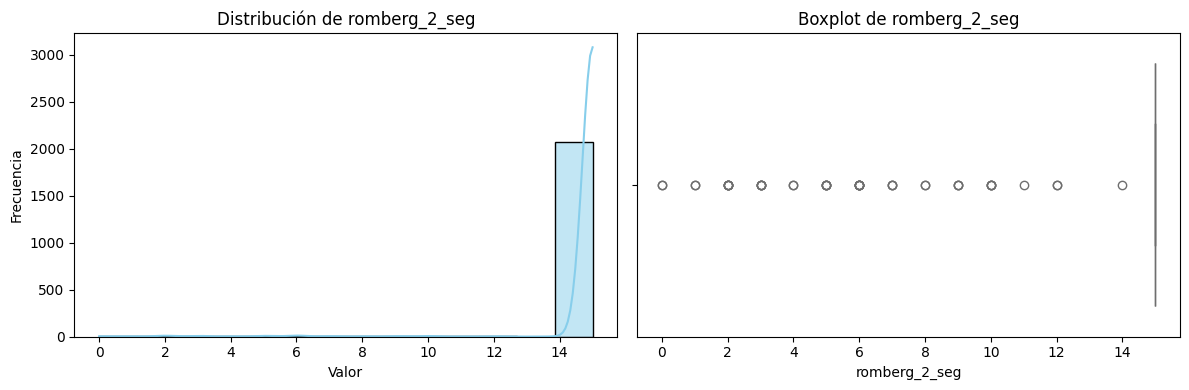

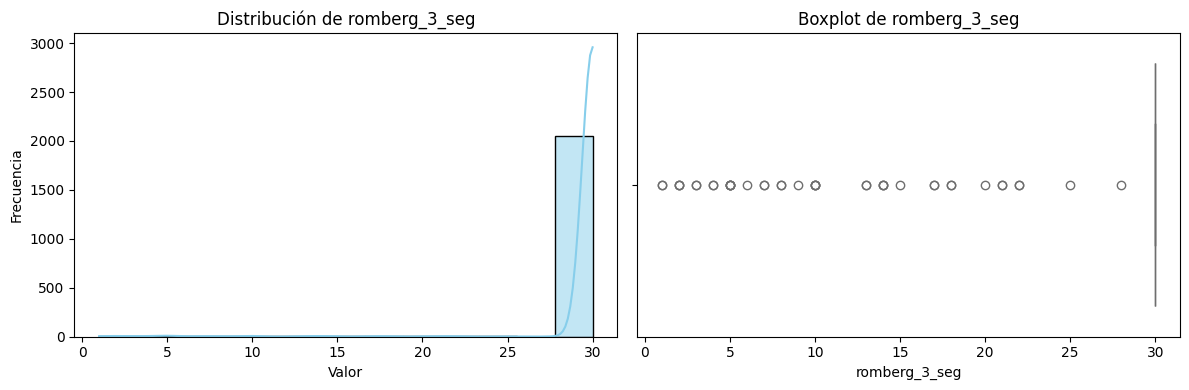

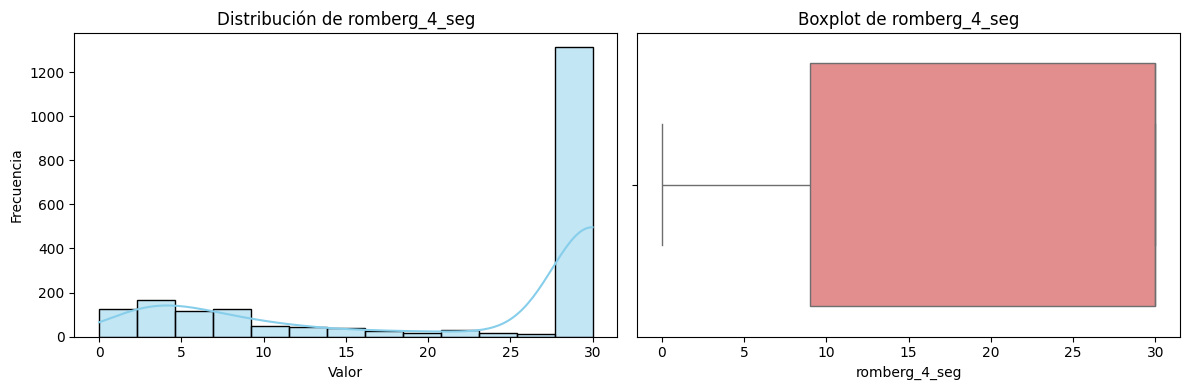

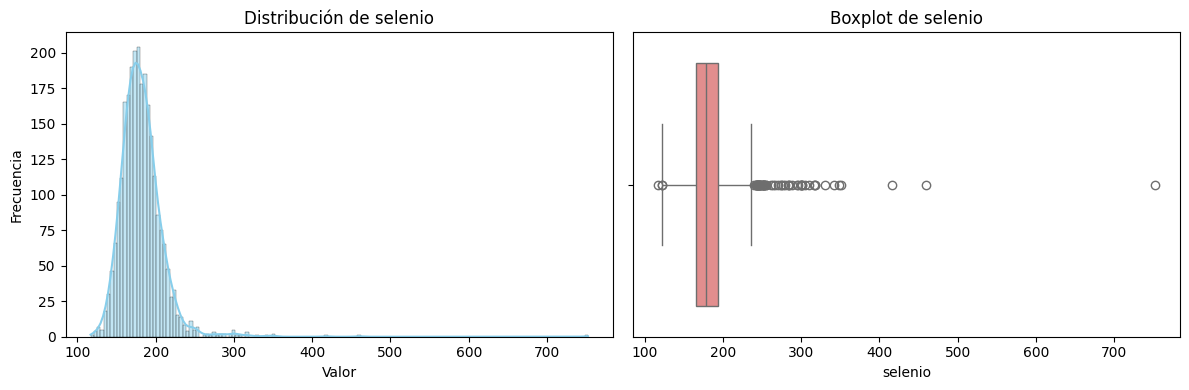

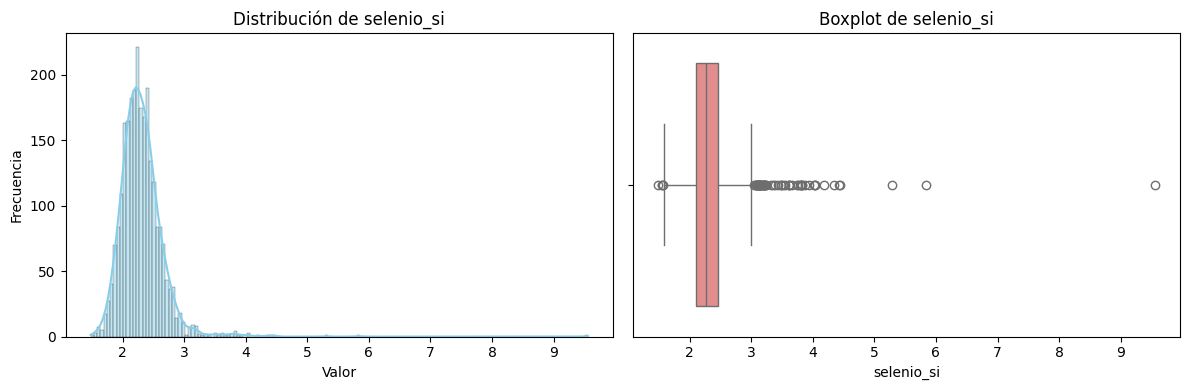

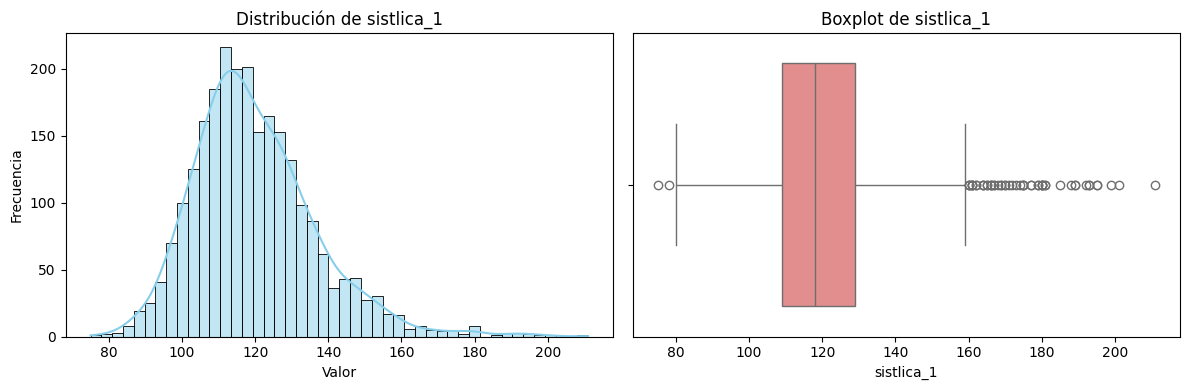

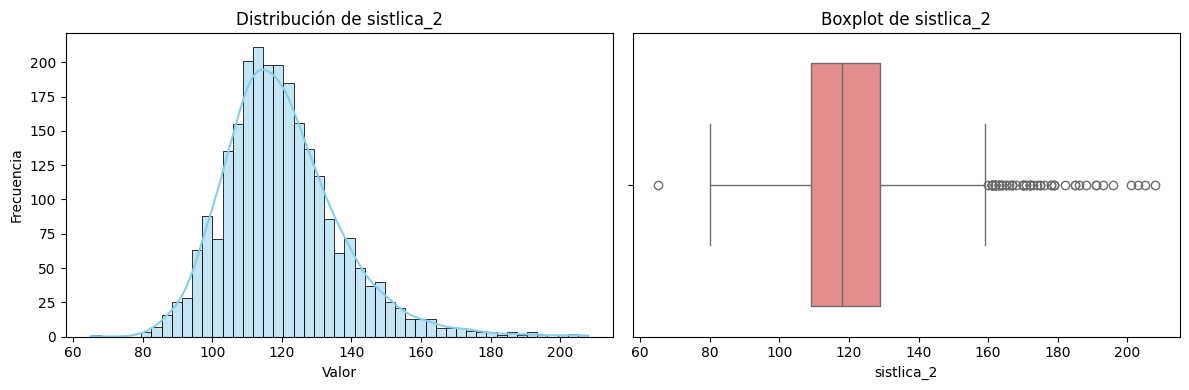

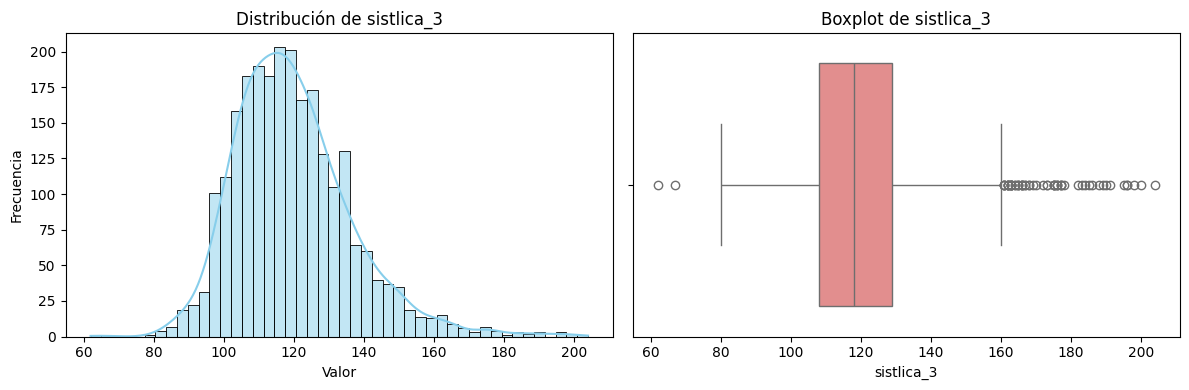

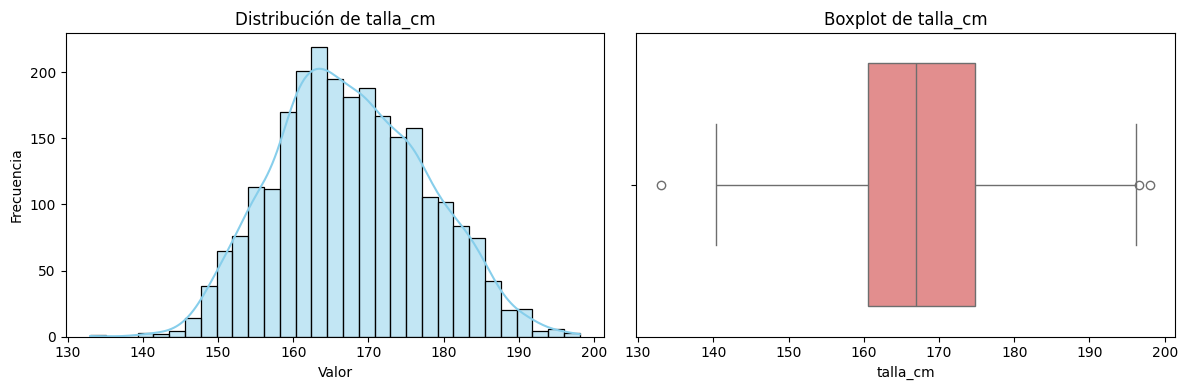

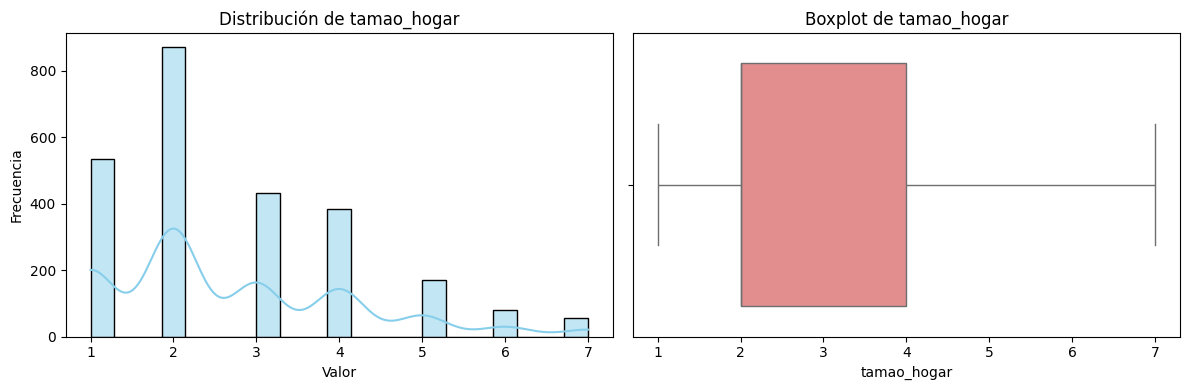

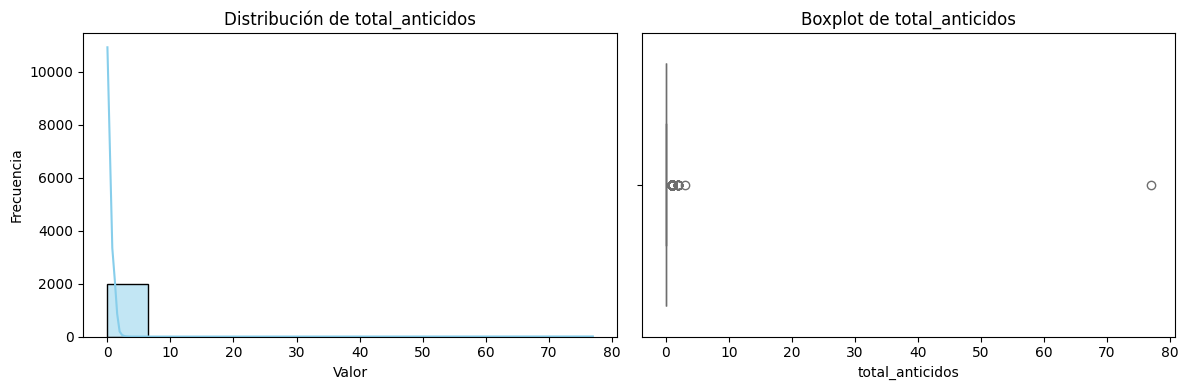

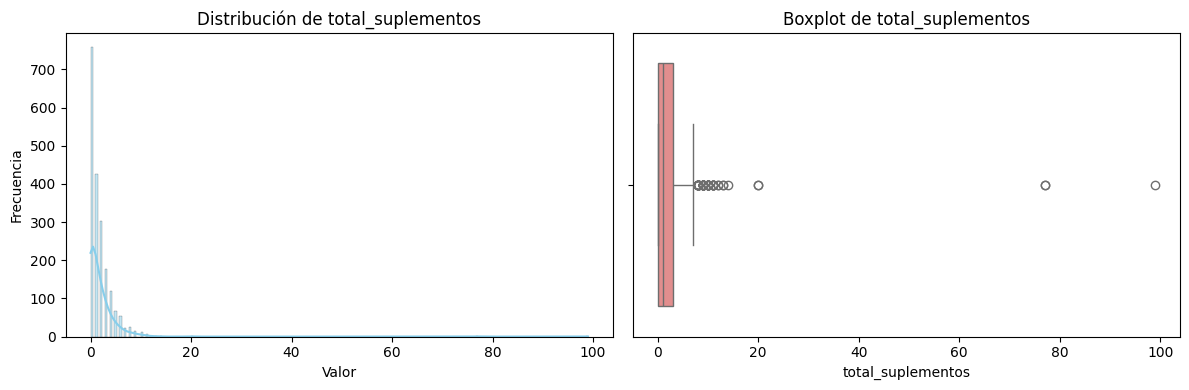

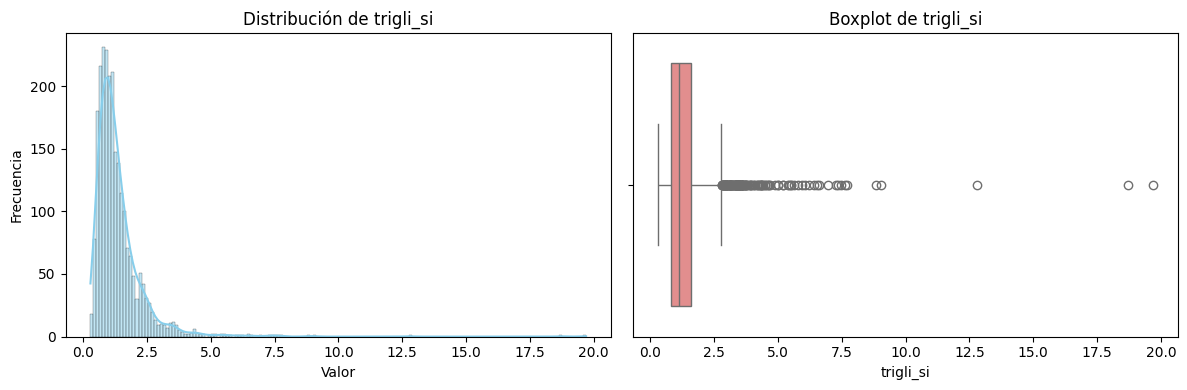

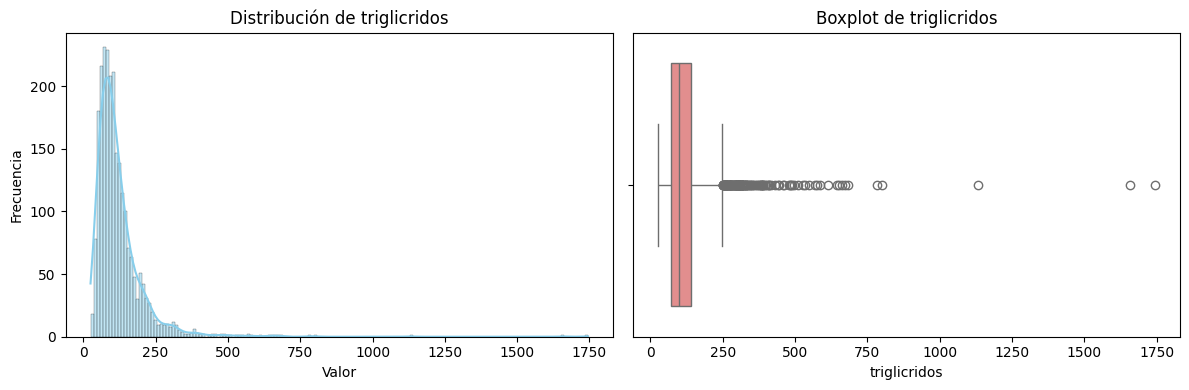

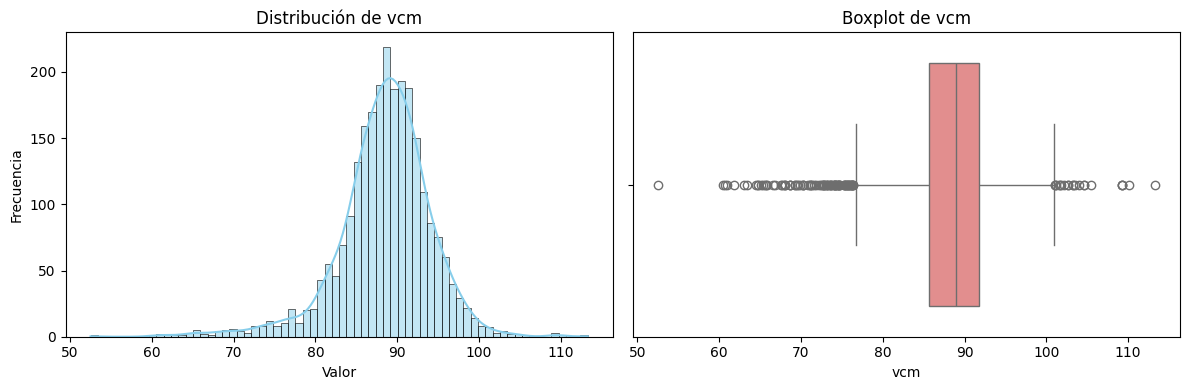

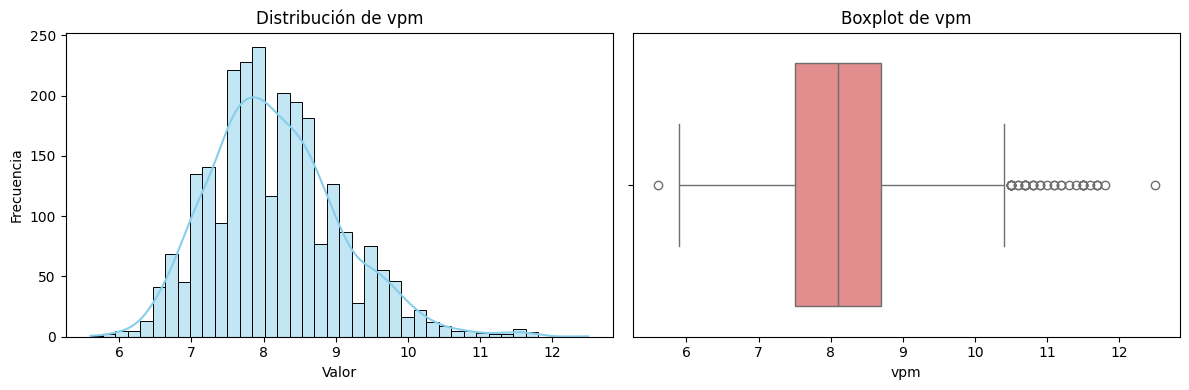

In [ ]:
# Definimos el número de variables a visualizar por tanda para no saturar el cuaderno
vars_a_revisar = cols_numericas # Puedes cambiar el rango o usar cols_numericas completa

for col in vars_a_revisar:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # Histograma con KDE 
    sns.histplot(df_clean_rows[col], kde=True, ax=axes[0], color='skyblue')
    axes[0].set_title(f'Distribución de {col}')
    axes[0].set_xlabel('Valor')
    axes[0].set_ylabel('Frecuencia')
    
    # Boxplot 
    sns.boxplot(x=df_clean_rows[col], ax=axes[1], color='lightcoral')
    axes[1].set_title(f'Boxplot de {col}')
    axes[1].set_xlabel(col)
    
    plt.tight_layout()
    plt.show()
    #TODO: Comentar!!

In [ ]:
def count_outliers(data):
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return ((data < lower_bound) | (data > upper_bound)).sum()

# Creamos un resumen
outlier_summary = []
for col in cols_numericas:
    n_outliers = count_outliers(df[col].dropna())
    pct_outliers = (n_outliers / len(df)) * 100
    outlier_summary.append({
        'Variable': col,
        'Num_Outliers': n_outliers,
        'Porcentaje': round(pct_outliers, 2)
    })

df_outliers = pd.DataFrame(outlier_summary).sort_values(by='Num_Outliers', ascending=False)

print("--- Outliers detectados ---")
print(df_outliers.to_string(index=False))
#TODO: Comentar!!

--- Outliers detectados ---
         Variable  Num_Outliers  Porcentaje
       med_vlidas           645       24.00
  total_anticidos           365       13.58
         intentos           324       12.06
     ratio_albcre           319       11.87
    albmina_orina           304       11.31
       albmina_si           304       11.31
           cadmio           261        9.71
        cadmio_si           261        9.71
  eosinofilos_abs           232        8.63
         mercurio           219        8.15
      mercurio_si           219        8.15
        protena_c           202        7.52
      rigidez_kpa           199        7.41
         plomo_si           170        6.33
      iqr_rigidez           170        6.33
            plomo           164        6.10
      peso_examen           150        5.58
              rdw           148        5.51
      peso_sangre           147        5.47
       peso_dieta           144        5.36
       peso_ayuno           141        5.25
    

- Hacer análisis de outliers, ¿los outliers coinciden con los pacientes que en la categoría presentan símtomas?

## Correlaciones

--- Estadísticos Principales ---


,edad,tamao_hogar,peso_entrevista,peso_examen,estrato,psu,ratio_pobreza,peso_dieta,total_suplementos,total_anticidos,...,plomo,plomo_si,cadmio,cadmio_si,mercurio,mercurio_si,selenio,selenio_si,manganeso,manganeso_si
count,2527.000000,2527.000000,2527.000000,2527.000000,2527.000000,2527.000000,2.214000e+03,2.527000e+03,1.995000e+03,1.990000e+03,...,2524.000000,2524.000000,2524.000000,2524.000000,2524.000000,2524.000000,2524.000000,2524.000000,2524.000000,2524.000000
mean,48.621686,2.699644,33826.990888,43509.468658,179.671547,1.491888,3.002191e+00,4.402875e+04,1.874185e+00,2.201005e-01,...,0.932163,0.045028,0.419276,3.730300,1.254782,6.261977,181.756894,2.308245,9.606668,174.860618
std,14.397566,1.469811,22867.286454,31066.251699,4.243825,0.500033,1.695412e+00,4.751253e+04,3.936776e+00,1.768616e+00,...,1.349416,0.065176,0.550688,4.899477,2.077207,10.364954,28.345781,0.360027,3.529597,64.245812
min,20.000000,1.000000,4584.463196,5424.587296,173.000000,1.000000,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,...,0.095000,0.005000,0.046000,0.409000,0.120000,0.600000,116.700000,1.480000,2.980000,54.240000
25%,36.000000,2.000000,17779.809672,21612.103335,176.000000,1.000000,1.440000e+00,1.364489e+04,5.397605e-79,5.397605e-79,...,0.447000,0.022000,0.158000,1.406000,0.230000,1.150000,165.175000,2.100000,7.270000,132.330000
50%,51.000000,2.000000,27391.039950,34519.232893,180.000000,1.000000,3.000000e+00,3.186998e+04,1.000000e+00,5.397605e-79,...,0.684500,0.033000,0.249000,2.215000,0.590000,2.940000,178.800000,2.270000,8.950000,162.910000
75%,62.000000,4.000000,42527.079160,55211.460010,183.000000,2.000000,5.000000e+00,6.027358e+04,3.000000e+00,5.397605e-79,...,1.065250,0.051000,0.439000,3.906000,1.412500,7.052500,193.900000,2.460000,11.150000,202.950000
max,69.000000,7.000000,170968.343177,227108.296958,187.000000,2.000000,5.000000e+00,4.085058e+05,9.900000e+01,7.700000e+01,...,48.070000,2.322000,7.684000,68.365000,29.540000,147.400000,752.400000,9.560000,42.950000,781.780000


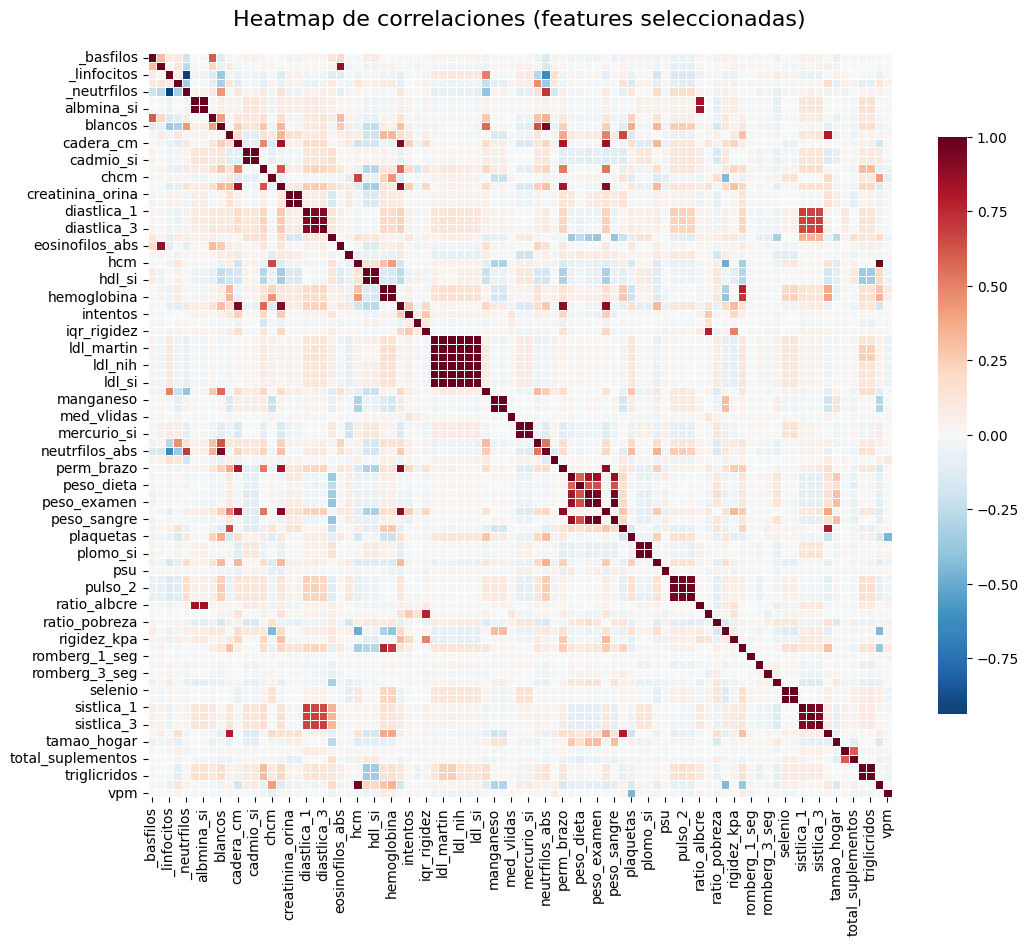

In [ ]:
# 3. Análisis Estadístico Descriptivo
print("--- Estadísticos Principales ---")
display(df_clean_rows.describe())

# 4. Visualización de correlación 
# Calculamos la matriz
corr_matrix = df_clean_rows[cols_numericas].corr()

# Configuramos el tamaño de la figura
plt.figure(figsize=(12, 10))

# Dibujamos el heatmap 
sns.heatmap(corr_matrix, 
            annot=False, 
            cmap='RdBu_r', 
            center=0,
            linewidths=.5, 
            linecolor='white',
            square=True,
            cbar_kws={"shrink": .75})

# Ajustes de etiquetas y título
plt.title("Heatmap de correlaciones (features seleccionadas)", fontsize=16, pad=20)
plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.show()
#TODO: Comentar!!

- Analizar las correlaciones entre variables.
- Eliminar redundancias y mirar posibles agrupaciones